# 06 LightFM Hybrid Recommender: Final Model, Regularization, and Evaluation

This notebook trains and evaluates LightFM models for the PixelRec50K recommender-system project.

The notebook covers:

1. Data loading and item-feature construction.
2. Interaction-only and hybrid LightFM baselines.
3. Feature ablation and hyperparameter tuning.
4. Final model selection using validation NDCG@10.
5. Regularization evidence: L2 sweep, embedding-size limits, and epoch learning curve.
6. Diagnostics: final comparison, user-level NDCG distribution, cold-item analysis, full-catalog sanity check, and one NDCG walkthrough.

Important evaluation note: the main ranking metrics use sampled candidate sets from the processed validation/test files. These metrics are useful for controlled model comparison, but they are easier than full-catalog ranking and should be interpreted as upper-bound proxy metrics. A small full-catalog sanity check is included near the end.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import pickle
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "lightfm", "lightfm-next"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "lightfm-next", "jieba"])
import numpy as np
import pandas as pd

from scipy.sparse import load_npz, csr_matrix, hstack, identity
from lightfm import LightFM

print("LightFM imported successfully.")

# LightFM does not use CUDA/GPU;
try:
    gpu_info = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=False
    )
    if gpu_info.returncode == 0 and gpu_info.stdout.strip():
        print("GPU detected by Colab:", gpu_info.stdout.strip())
        print("Note: LightFM still trains on CPU; NUM_THREADS controls speed.")
    else:
        print("No GPU detected. This is acceptable for LightFM because training is CPU-based.")
except Exception as e:
    print("GPU check skipped:", e)


Mounted at /content/drive
LightFM imported successfully.
GPU detected by Colab: Tesla T4, 15360 MiB
Note: LightFM still trains on CPU; NUM_THREADS controls speed.


## 1. Load Processed Data

In [2]:
import os
import pickle
import numpy as np
import pandas as pd

from scipy.sparse import load_npz, csr_matrix, hstack, identity

DATASET_DIR = "/content/drive/MyDrive/PixelRec50K"
PROCESSED_DIR = os.path.join(DATASET_DIR, "processed")

OUTPUT_ROOT = "/content/drive/MyDrive/PixelRec50K_outputs"
RESULT_DIR = os.path.join(OUTPUT_ROOT, "results")
MODEL_DIR = os.path.join(OUTPUT_ROOT, "models")

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(PROCESSED_DIR, "train_5core.csv"))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, "val_5core.csv"))
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test_5core.csv"))

train_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "train_samples_5core.csv"))
val_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "val_samples_5core.csv"))
test_samples = pd.read_csv(os.path.join(PROCESSED_DIR, "test_samples_5core.csv"))

item_features_df = pd.read_csv(os.path.join(PROCESSED_DIR, "item_features_5core.csv"))
train_matrix = load_npz(os.path.join(PROCESSED_DIR, "train_interaction_matrix_5core.npz"))

num_users, num_items = train_matrix.shape
NUM_THREADS = 4
RANDOM_STATE = 42

print("Train matrix:", train_matrix.shape)
print("Train interactions:", train_matrix.nnz)
print("Validation samples:", val_samples.shape)
print("Test samples:", test_samples.shape)
print("Item features:", item_features_df.shape)
print("Results will be saved to:", RESULT_DIR)
print("Models will be saved to:", MODEL_DIR)

Train matrix: (49950, 47322)
Train interactions: 711060
Validation samples: (538458, 3)
Test samples: (678144, 3)
Item features: (47322, 126)
Results will be saved to: /content/drive/MyDrive/PixelRec50K_outputs/results
Models will be saved to: /content/drive/MyDrive/PixelRec50K_outputs/models


## 2. Set Hybrid Item Features

In [3]:
item_features_df = item_features_df.sort_values("item_idx").reset_index(drop=True)

assert item_features_df["item_idx"].nunique() == num_items
assert item_features_df["item_idx"].min() == 0
assert item_features_df["item_idx"].max() == num_items - 1

metadata_feature_cols = [
    c for c in item_features_df.columns
    if c not in ["item_id", "item_idx"]
]

metadata_features = csr_matrix(
    item_features_df[metadata_feature_cols].values.astype(np.float32)
)

item_identity_features = identity(num_items, format="csr", dtype=np.float32)

# Identity features give each item a free per-item embedding, so LightFM can behave like
# matrix factorization for warm items.
hybrid_item_features = hstack(
    [item_identity_features, metadata_features],
    format="csr"
)

print("Metadata feature matrix:", metadata_features.shape)
print("Hybrid item feature matrix:", hybrid_item_features.shape)

Metadata feature matrix: (47322, 124)
Hybrid item feature matrix: (47322, 47446)


## 3. Train Interaction-Only LightFM

In [4]:
!pip uninstall -y lightfm lightfm-next
!pip install -q --no-cache-dir lightfm-next jieba

Found existing installation: lightfm-next 1.19.0
Uninstalling lightfm-next-1.19.0:
  Successfully uninstalled lightfm-next-1.19.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.9 MB/s eta 0:00:00


In [5]:
from lightfm import LightFM
print("LightFM imported successfully.")

LightFM imported successfully.


In [6]:
# WARP loss directly optimizes Top-N ranking for implicit feedback.
interaction_model = LightFM(
    loss="warp",
    no_components=64,
    learning_rate=0.05,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=RANDOM_STATE
)

interaction_model.fit(
    train_matrix,
    epochs=40,
    num_threads=NUM_THREADS,
    verbose=True
)

Epoch: 100%|██████████| 40/40 [01:06<00:00,  1.67s/it]


## 4. Train Hybrid LightFM

In [7]:
# Same initial hyperparameters as the interaction-only model, now with hybrid item features.
# To isolates the effect of adding metadata before later tuning the final feature set.
hybrid_model = LightFM(
    loss="warp",
    no_components=64,
    learning_rate=0.05,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=RANDOM_STATE
)

hybrid_model.fit(
    train_matrix,
    item_features=hybrid_item_features,
    epochs=40,
    num_threads=NUM_THREADS,
    verbose=True
)

Epoch: 100%|██████████| 40/40 [03:33<00:00,  5.33s/it]


## Evaluation Metrics

Evaluate LightFM using candidate-based Precision@K, Recall@K, and NDCG@K. Candidate sets come from the validation/test samples and include positive interactions plus sampled negative items.

In [8]:
def precision_at_k(recommended, relevant, k):
    # fraction of top-K recommended items that are relevant.
    recommended_k = recommended[:k]
    if len(recommended_k) == 0:
        return 0.0
    return len(set(recommended_k) & set(relevant)) / k

def recall_at_k(recommended, relevant, k):
    # fraction of all relevant candidate items recovered in top-K.
    if len(relevant) == 0:
        return 0.0
    recommended_k = recommended[:k]
    return len(set(recommended_k) & set(relevant)) / len(set(relevant))

def ndcg_at_k(recommended, relevant, k):
    # Return binary NDCG@K for a ranked item-id list.
    relevant = set(relevant)
    dcg = 0.0

    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)

    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    if idcg == 0:
        return 0.0

    return dcg / idcg

In [9]:
def evaluate_lightfm_on_samples(model, samples_df, item_features=None, k_values=[5, 10, 20], num_threads=NUM_THREADS):
    #Candidate-based LightFM evaluation.
    rows = []

    for user_idx, user_data in samples_df.groupby("user_idx", sort=False):
        candidate_items = user_data["item_idx"].values.astype(np.int32)
        relevant_items = user_data.loc[user_data["label"] == 1, "item_idx"].unique().tolist()

        user_array = np.full(len(candidate_items), int(user_idx), dtype=np.int32)

        scores = model.predict(
            user_ids=user_array,
            item_ids=candidate_items,
            item_features=item_features,
            num_threads=num_threads
        )

        ranked_items = candidate_items[np.argsort(-scores)].tolist()

        for k in k_values:
            rows.append({
                "user_idx": int(user_idx),
                "k": int(k),
                "precision": precision_at_k(ranked_items, relevant_items, k),
                "recall": recall_at_k(ranked_items, relevant_items, k),
                "ndcg": ndcg_at_k(ranked_items, relevant_items, k)
            })

    user_results = pd.DataFrame(rows)

    summary = (
        user_results
        .groupby("k")[["precision", "recall", "ndcg"]]
        .mean()
        .reset_index()
    )

    return summary, user_results

print("Evaluation mode: candidate-based ranking within sampled positive/negative candidates.")
print("Interpretation note: these metrics are upper-bound proxies, not full-catalog production metrics.")

Evaluation mode: candidate-based ranking within sampled positive/negative candidates.
Interpretation note: these metrics are upper-bound proxies, not full-catalog production metrics.


## Evaluate Interaction-Only LightFM

In [10]:
interaction_train_summary, _ = evaluate_lightfm_on_samples(
    interaction_model,
    train_samples,
    item_features=None,
    k_values=[5, 10, 20]
)

interaction_val_summary, _ = evaluate_lightfm_on_samples(
    interaction_model,
    val_samples,
    item_features=None,
    k_values=[5, 10, 20]
)

interaction_test_summary, _ = evaluate_lightfm_on_samples(
    interaction_model,
    test_samples,
    item_features=None,
    k_values=[5, 10, 20]
)

print("Interaction-Only Train Results")
display(interaction_train_summary)

print("Interaction-Only Validation Results")
display(interaction_val_summary)

print("Interaction-Only Test Results")
display(interaction_test_summary)

Interaction-Only Train Results


,k,precision,recall,ndcg
0,5,0.994230,0.497175,0.999184
1,10,0.874440,0.802453,0.999219
2,20,0.586729,0.945456,0.999361


Interaction-Only Validation Results


,k,precision,recall,ndcg
0,5,0.221992,0.773314,0.575953
1,10,0.144996,0.923193,0.635492
2,20,0.083629,0.982852,0.658237


Interaction-Only Test Results


,k,precision,recall,ndcg
0,5,0.203868,0.573967,0.426176
1,10,0.160038,0.833497,0.529872
2,20,0.101382,0.966947,0.578914


In [11]:
# dynamic_interaction_summary
interaction_test_k10 = interaction_test_summary[interaction_test_summary["k"] == 10].iloc[0]
print(
    "Interaction-only LightFM Test@10\n"
    f"  Precision: {interaction_test_k10['precision']:.3f}\n"
    f"  Recall:    {interaction_test_k10['recall']:.3f}\n"
    f"  NDCG:      {interaction_test_k10['ndcg']:.3f}"
)

Interaction-only LightFM Test@10
  Precision: 0.160
  Recall:    0.833
  NDCG:      0.530


The interaction-only LightFM model achieves a Test@10 Precision of 0.160, Recall of 0.833, and NDCG of 0.530. This shows that user-item interaction history alone provides meaningful personalization beyond a non-personalized baseline.

The high Recall@10 suggests that the model retrieves many relevant items, while the moderate Precision@10 indicates that ranking quality can still be improved with item metadata and hybrid features.

## Evaluate Hybrid LightFM

In [12]:
hybrid_train_summary, _ = evaluate_lightfm_on_samples(
    hybrid_model,
    train_samples,
    item_features=hybrid_item_features,
    k_values=[5, 10, 20]
)

hybrid_val_summary, _ = evaluate_lightfm_on_samples(
    hybrid_model,
    val_samples,
    item_features=hybrid_item_features,
    k_values=[5, 10, 20]
)

hybrid_test_summary, _ = evaluate_lightfm_on_samples(
    hybrid_model,
    test_samples,
    item_features=hybrid_item_features,
    k_values=[5, 10, 20]
)

print("Hybrid Train Results")
display(hybrid_train_summary)

print("Hybrid Validation Results")
display(hybrid_val_summary)

print("Hybrid Test Results")
display(hybrid_test_summary)

Hybrid Train Results


,k,precision,recall,ndcg
0,5,0.990378,0.495595,0.995315
1,10,0.871161,0.800428,0.995641
2,20,0.585022,0.944192,0.996692


Hybrid Validation Results


,k,precision,recall,ndcg
0,5,0.250750,0.832973,0.660188
1,10,0.155260,0.949773,0.706889
2,20,0.086031,0.989898,0.722576


Hybrid Test Results


,k,precision,recall,ndcg
0,5,0.250054,0.671214,0.528158
1,10,0.178252,0.888899,0.616741
2,20,0.105399,0.979910,0.651197


In [13]:
# dynamic_hybrid_summary: print fresh values from the current run instead of hard-coding metrics.
hybrid_test_k10 = hybrid_test_summary[hybrid_test_summary["k"] == 10].iloc[0]
interaction_test_k10 = interaction_test_summary[interaction_test_summary["k"] == 10].iloc[0]
print(
    "Hybrid LightFM Test@10\n"
    f"  Precision: {hybrid_test_k10['precision']:.3f}\n"
    f"  Recall:    {hybrid_test_k10['recall']:.3f}\n"
    f"  NDCG:      {hybrid_test_k10['ndcg']:.3f}\n"
    f"  NDCG lift vs interaction-only: {hybrid_test_k10['ndcg'] - interaction_test_k10['ndcg']:.3f}"
)

Hybrid LightFM Test@10
  Precision: 0.178
  Recall:    0.889
  NDCG:      0.617
  NDCG lift vs interaction-only: 0.087


The hybrid LightFM model improves over the interaction-only version across all Test@10 metrics. NDCG increases from 0.530 to 0.617, a lift of 0.087, showing that item metadata adds useful ranking signal beyond user-item interactions alone.

The higher Recall@10 also suggests that hybrid features help retrieve more relevant videos.

## Save and Compare Results

In [14]:
def format_result(summary_df, model_name, features, split):
    # Attach model metadata to a metric summary
    out = summary_df.copy()
    out["model"] = model_name
    out["features"] = features
    out["split"] = split
    return out[["model", "features", "split", "k", "precision", "recall", "ndcg"]]

lightfm_results = pd.concat([
    format_result(
        interaction_train_summary,
        "LightFM Interaction-Only",
        "User-item interactions",
        "train"
    ),
    format_result(
        interaction_val_summary,
        "LightFM Interaction-Only",
        "User-item interactions",
        "validation"
    ),
    format_result(
        interaction_test_summary,
        "LightFM Interaction-Only",
        "User-item interactions",
        "test"
    ),
    format_result(
        hybrid_train_summary,
        "LightFM Hybrid",
        "User-item interactions + item metadata",
        "train"
    ),
    format_result(
        hybrid_val_summary,
        "LightFM Hybrid",
        "User-item interactions + item metadata",
        "validation"
    ),
    format_result(
        hybrid_test_summary,
        "LightFM Hybrid",
        "User-item interactions + item metadata",
        "test"
    )
], ignore_index=True)

lightfm_results.to_csv(
    os.path.join(RESULT_DIR, "lightfm_results.csv"),
    index=False
)

display(lightfm_results)
print("Saved LightFM results to:", os.path.join(RESULT_DIR, "lightfm_results.csv"))

,model,features,split,k,precision,recall,ndcg
0,LightFM Interaction-Only,User-item interactions,train,5,0.994230,0.497175,0.999184
1,LightFM Interaction-Only,User-item interactions,train,10,0.874440,0.802453,0.999219
2,LightFM Interaction-Only,User-item interactions,train,20,0.586729,0.945456,0.999361
3,LightFM Interaction-Only,User-item interactions,validation,5,0.221992,0.773314,0.575953
4,LightFM Interaction-Only,User-item interactions,validation,10,0.144996,0.923193,0.635492
5,LightFM Interaction-Only,User-item interactions,validation,20,0.083629,0.982852,0.658237
6,LightFM Interaction-Only,User-item interactions,test,5,0.203868,0.573967,0.426176
7,LightFM Interaction-Only,User-item interactions,test,10,0.160038,0.833497,0.529872
8,LightFM Interaction-Only,User-item interactions,test,20,0.101382,0.966947,0.578914
9,LightFM Hybrid,User-item interactions + item metadata,train,5,0.990378,0.495595,0.995315


Saved LightFM results to: /content/drive/MyDrive/PixelRec50K_outputs/results/lightfm_results.csv


## Initial LightFM Comparison Summary

The interaction-only and initial hybrid LightFM models are summarized here before the extended text/metadata ablation study.

In [15]:
metrics = ["precision", "recall", "ndcg"]

initial_k10_summary = (
    lightfm_results[
        (lightfm_results["split"].isin(["validation", "test"])) &
        (lightfm_results["k"] == 10)
    ]
    .sort_values(["split", "model"])
    .reset_index(drop=True)
)

display(initial_k10_summary)

initial_test_k10 = lightfm_results[
    (lightfm_results["split"] == "test") &
    (lightfm_results["k"] == 10)
].copy()

if set(["LightFM Interaction-Only", "LightFM Hybrid"]).issubset(set(initial_test_k10["model"])):
    interaction_row = initial_test_k10[initial_test_k10["model"] == "LightFM Interaction-Only"].iloc[0]
    hybrid_row = initial_test_k10[initial_test_k10["model"] == "LightFM Hybrid"].iloc[0]

    initial_lift = pd.DataFrame({
        "metric": metrics,
        "interaction_only": [interaction_row[m] for m in metrics],
        "hybrid": [hybrid_row[m] for m in metrics]
    })
    initial_lift["absolute_lift"] = initial_lift["hybrid"] - initial_lift["interaction_only"]
    initial_lift["relative_lift_pct"] = initial_lift["absolute_lift"] / initial_lift["interaction_only"] * 100

    display(initial_lift)
    initial_lift.to_csv(os.path.join(RESULT_DIR, "lightfm_initial_hybrid_lift_k10.csv"), index=False)

,model,features,split,k,precision,recall,ndcg
0,LightFM Hybrid,User-item interactions + item metadata,test,10,0.178252,0.888899,0.616741
1,LightFM Interaction-Only,User-item interactions,test,10,0.160038,0.833497,0.529872
2,LightFM Hybrid,User-item interactions + item metadata,validation,10,0.155260,0.949773,0.706889
3,LightFM Interaction-Only,User-item interactions,validation,10,0.144996,0.923193,0.635492


,metric,interaction_only,hybrid,absolute_lift,relative_lift_pct
0,precision,0.160038,0.178252,0.018214,11.381178
1,recall,0.833497,0.888899,0.055402,6.646891
2,ndcg,0.529872,0.616741,0.086870,16.394457


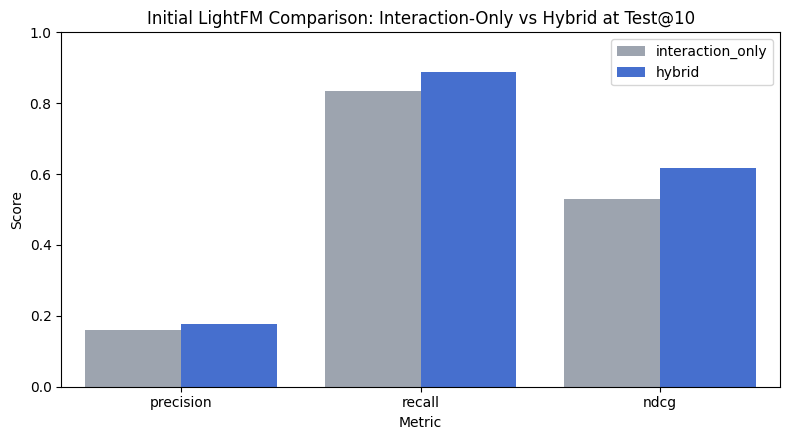

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

if "initial_lift" in globals():
    plot_df = initial_lift.melt(
        id_vars=["metric"],
        value_vars=["interaction_only", "hybrid"],
        var_name="model",
        value_name="score"
    )

    plt.figure(figsize=(8, 4.5))
    sns.barplot(
        data=plot_df,
        x="metric",
        y="score",
        hue="model",
        palette={
            "interaction_only": "#9aa4b2",
            "hybrid": "#2f66e5"
        }
    )

    plt.title("Initial LightFM Comparison: Interaction-Only vs Hybrid at Test@10")
    plt.xlabel("Metric")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

# Text and Metadata Ablation Study

In [17]:
from scipy.sparse import csr_matrix, hstack, identity
import numpy as np
import pandas as pd
import os
import pickle

## 1. Load Text SVD Features

The text features were created from item titles and descriptions using TF-IDF followed by TruncatedSVD.

In [18]:
# Versioned output path prevents accidentally reusing older text features built with the English tokenizer.
text_svd_path = os.path.join(PROCESSED_DIR, "text_svd_features_64_jieba.csv")
item_info_path = os.path.join(DATASET_DIR, "pixel50k_item_info.csv")
item_info_full = pd.read_csv(item_info_path)

# Show sample titles to confirm whether tokenization needs to handle Chinese characters.
# PixelRec is a Chinese short-video dataset
print("Sample item titles for tokenizer sanity check:")
display(item_info_full[["item_id", "title"]].dropna().head(10))

if os.path.exists(text_svd_path):
    text_svd_df = pd.read_csv(text_svd_path)
    print("Loaded existing jieba text SVD features:", text_svd_df.shape)
    assert "item_id" in text_svd_df.columns, "text SVD file must contain item_id for metadata alignment."
    coverage = text_svd_df["item_id"].isin(item_info_full["item_id"]).mean()
    print(f"Coverage in item_info: {coverage:.2%}")
    assert coverage > 0.99, "Text SVD item_id coverage is unexpectedly low. Rebuild text features."
else:
    print("text_svd_features_64_jieba.csv not found. Rebuilding text features from item_info with jieba tokenizer...")

    try:
        import jieba
    except ImportError:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "jieba"])
        import jieba

    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD

    text_series = (
        item_info_full["title"].fillna("").astype(str)
        + " "
        + item_info_full["description"].fillna("").astype(str)
    )

    def jieba_tokenizer(text):
        """Tokenize Chinese/English mixed titles and descriptions for TF-IDF."""
        return [token.strip() for token in jieba.lcut(str(text)) if token.strip()]

    tfidf = TfidfVectorizer(
        tokenizer=jieba_tokenizer,
        token_pattern=None,
        lowercase=False,
        max_features=5000,
        min_df=3,
        max_df=0.8
    )

    tfidf_matrix = tfidf.fit_transform(text_series)

    svd = TruncatedSVD(n_components=64, random_state=RANDOM_STATE)
    text_embeddings = svd.fit_transform(tfidf_matrix)

    text_svd_df = pd.DataFrame(
        text_embeddings,
        columns=[f"text_svd_{i}" for i in range(text_embeddings.shape[1])]
    )

    text_svd_df.insert(0, "item_id", item_info_full["item_id"].values)

    text_svd_df.to_csv(text_svd_path, index=False)

    print("Rebuilt and saved jieba text SVD features:", text_svd_df.shape)
    print("Saved to:", text_svd_path)
    print("Explained variance ratio:", svd.explained_variance_ratio_.sum())

display(text_svd_df.head())

Sample item titles for tokenizer sanity check:


,item_id,title
0,i192714,"My boyfriend gave me a turtle, and it suddenly..."
1,i225967,Who's not a baby anymore! Alaska is being bull...
2,i8061,New York subway rules that pets can't ride the...
3,i217203,The biggest dog in the world. It's so ugly and...
4,i349133,Taylor Swift: Selena and Mould perform Hands T...
5,i349132,Neighborhood door warning Shallow listening to...
6,i349130,Feng Mo DIO VS Chong Huang JOJO
7,i349124,DIO's bad adventures] JOJO invincible edition
8,i214047,[Ruined Childhood] I didn't realize you were s...
9,i401598,"Mom, Fu Jing was kissed to the shy red face, W..."


Loaded existing jieba text SVD features: (82865, 65)
Coverage in item_info: 100.00%


,item_id,text_svd_0,text_svd_1,text_svd_2,text_svd_3,text_svd_4,text_svd_5,text_svd_6,text_svd_7,text_svd_8,...,text_svd_54,text_svd_55,text_svd_56,text_svd_57,text_svd_58,text_svd_59,text_svd_60,text_svd_61,text_svd_62,text_svd_63
0,i192714,0.149370,-0.023417,-0.102199,0.047699,-0.050430,0.009622,-0.002696,-0.044634,0.035733,...,0.000824,-0.053682,-0.012538,0.020516,0.005454,0.020452,0.000164,0.002237,-0.007182,0.028768
1,i225967,0.180581,0.045053,-0.079248,0.070083,0.142873,-0.076271,-0.066041,0.014701,0.106140,...,-0.054100,0.011331,-0.044042,-0.020315,0.019824,-0.060924,0.024157,0.054990,-0.016345,-0.035060
2,i8061,0.133670,-0.033725,-0.049751,0.026869,-0.017617,-0.012592,-0.019415,0.057834,0.074130,...,-0.082924,0.017985,0.001022,-0.012637,0.049043,-0.057093,-0.015339,0.044892,-0.066929,-0.048102
3,i217203,0.325482,-0.034243,-0.011708,-0.028516,-0.048640,-0.039551,0.017078,0.134812,0.002352,...,0.092911,-0.001347,-0.002751,-0.034097,-0.042446,0.028979,0.149492,-0.063039,-0.054788,0.031414
4,i349133,0.039764,0.029650,0.008360,-0.011790,0.014416,-0.020384,-0.006709,-0.040546,0.022029,...,-0.003556,0.005249,-0.006892,-0.002594,-0.002109,0.004569,-0.004972,0.001964,-0.001061,-0.002878


## 2. Merge Text Features With Existing Item Features

I align text features to the 5-core item set by `item_id`, then sort by `item_idx` to ensure correct LightFM feature alignment.

In [19]:
item_feature_base = item_features_df.copy()

item_feature_text = (
    item_feature_base[["item_id", "item_idx"]]
    .merge(text_svd_df, on="item_id", how="left")
    .sort_values("item_idx")
    .reset_index(drop=True)
)

text_cols = [c for c in item_feature_text.columns if c.startswith("text_svd_")]

missing_text_rows = item_feature_text[text_cols].isna().any(axis=1).sum()
print("Missing text feature rows after merge:", missing_text_rows)

item_feature_text[text_cols] = item_feature_text[text_cols].fillna(0.0)

assert item_feature_text["item_idx"].nunique() == num_items
assert item_feature_text["item_idx"].min() == 0
assert item_feature_text["item_idx"].max() == num_items - 1

print("Aligned text feature table:", item_feature_text.shape)

Missing text feature rows after merge: 0
Aligned text feature table: (47322, 66)


## 3. Build Item Feature Groups

Separate item features into groups so we can test which feature types improve recommendation performance.

Feature groups:

- Tag features
- Numeric engagement metadata
- Basic text length features
- TF-IDF/SVD text features
- Full metadata features

In [20]:
base_cols = ["item_id", "item_idx"]

tag_cols = [c for c in item_features_df.columns if c.startswith("tag_")]

numeric_cols = [
    c for c in item_features_df.columns
    if c.startswith("scaled_log_")
]

text_length_cols = [
    c for c in item_features_df.columns
    if c in ["scaled_title_length", "scaled_description_length"]
]

text_svd_cols = text_cols

print("Tag features:", len(tag_cols))
print("Numeric metadata features:", len(numeric_cols))
print("Text length features:", len(text_length_cols))
print("Text SVD features:", len(text_svd_cols))

Tag features: 115
Numeric metadata features: 7
Text length features: 2
Text SVD features: 64


In [21]:
# metadata_column_audit: verify how the broad initial hybrid feature set differs from named ablation groups.
expected_existing_metadata_cols = set(tag_cols) | set(numeric_cols) | set(text_length_cols)
actual_initial_hybrid_cols = set(metadata_feature_cols)
extra_initial_hybrid_cols = sorted(actual_initial_hybrid_cols - expected_existing_metadata_cols)
missing_from_initial_hybrid_cols = sorted(expected_existing_metadata_cols - actual_initial_hybrid_cols)

metadata_column_audit = pd.DataFrame({
    "check": [
        "initial_hybrid_metadata_cols",
        "existing_metadata_ablation_cols",
        "extra_cols_in_initial_hybrid",
        "expected_cols_missing_from_initial_hybrid"
    ],
    "count": [
        len(actual_initial_hybrid_cols),
        len(expected_existing_metadata_cols),
        len(extra_initial_hybrid_cols),
        len(missing_from_initial_hybrid_cols)
    ],
    "examples": [
        sorted(list(actual_initial_hybrid_cols))[:10],
        sorted(list(expected_existing_metadata_cols))[:10],
        extra_initial_hybrid_cols[:10],
        missing_from_initial_hybrid_cols[:10]
    ]
})

display(metadata_column_audit)
if extra_initial_hybrid_cols:
    print("Note: the initial broad LightFM Hybrid uses extra metadata columns beyond the named ablation groups.")
    print("These models should be reported as separate configurations rather than duplicates.")

,check,count,examples
0,initial_hybrid_metadata_cols,124,"[scaled_description_length, scaled_log_barrage..."
1,existing_metadata_ablation_cols,124,"[scaled_description_length, scaled_log_barrage..."
2,extra_cols_in_initial_hybrid,0,[]
3,expected_cols_missing_from_initial_hybrid,0,[]


In [22]:
def build_item_feature_matrix(feature_dfs_and_cols, include_identity=True):
    #Build the LightFM item-feature matrix for a selected set of feature groups.

    matrices = []

    if include_identity:
        matrices.append(identity(num_items, format="csr", dtype=np.float32))

    for df, cols in feature_dfs_and_cols:
        if len(cols) == 0:
            continue

        aligned_df = df.sort_values("item_idx").reset_index(drop=True)

        assert aligned_df["item_idx"].nunique() == num_items
        assert aligned_df["item_idx"].min() == 0
        assert aligned_df["item_idx"].max() == num_items - 1

        matrix = csr_matrix(aligned_df[cols].values.astype(np.float32))
        matrices.append(matrix)

    if len(matrices) == 1:
        return matrices[0]

    return hstack(matrices, format="csr")

In [23]:
# Build one item-feature matrix per ablation group.
feature_matrices = {}

feature_matrices["tag_only"] = build_item_feature_matrix([
    (item_features_df, tag_cols)
])

feature_matrices["text_svd_only"] = build_item_feature_matrix([
    (item_feature_text, text_svd_cols)
])

feature_matrices["numeric_only"] = build_item_feature_matrix([
    (item_features_df, numeric_cols)
])

feature_matrices["metadata_existing"] = build_item_feature_matrix([
    (item_features_df, tag_cols + numeric_cols + text_length_cols)
])

feature_matrices["full_text_metadata"] = build_item_feature_matrix([
    (item_features_df, tag_cols + numeric_cols + text_length_cols),
    (item_feature_text, text_svd_cols)
])

for name, matrix in feature_matrices.items():
    print(name, matrix.shape)

tag_only (47322, 47437)
text_svd_only (47322, 47386)
numeric_only (47322, 47329)
metadata_existing (47322, 47446)
full_text_metadata (47322, 47510)


## 4. Train and Evaluate Ablation Models

Each model uses the same train/validation/test split and the same evaluation metrics. Compare feature groups using validation and test Precision@K, Recall@K, and NDCG@K.

In [24]:
def train_lightfm_model(item_features=None, epochs=40, no_components=64, learning_rate=0.05,
                        item_alpha=1e-6, user_alpha=1e-6, random_state=RANDOM_STATE,
                        num_threads=NUM_THREADS, verbose=True):
    # Train one LightFM WARP model with explicit hyperparameters.
    model = LightFM(
        loss="warp",
        no_components=no_components,
        learning_rate=learning_rate,
        item_alpha=item_alpha,
        user_alpha=user_alpha,
        random_state=random_state
    )

    model.fit(
        train_matrix,
        item_features=item_features,
        epochs=epochs,
        num_threads=num_threads,
        verbose=verbose
    )

    return model

def save_model(model, model_name):
    safe_name = model_name.lower().replace(" ", "_").replace("/", "_").replace("+", "plus")
    path = os.path.join(MODEL_DIR, f"{safe_name}.pkl")
    with open(path, "wb") as f:
        pickle.dump(model, f)
    return path

In [25]:
def evaluate_and_format(model, model_name, features_desc, item_features=None, evaluate_train=False, k_values=[5, 10, 20]):
    # Evaluate a LightFM model and return both aggregate and user-level results.

    result_parts = []
    user_result_parts = []

    if evaluate_train:
        train_summary, train_user_results = evaluate_lightfm_on_samples(
            model,
            train_samples,
            item_features=item_features,
            k_values=k_values
        )
        result_parts.append(format_result(train_summary, model_name, features_desc, "train"))
        train_user_results["split"] = "train"
        train_user_results["model"] = model_name
        user_result_parts.append(train_user_results)

    val_summary, val_user_results = evaluate_lightfm_on_samples(
        model,
        val_samples,
        item_features=item_features,
        k_values=k_values
    )

    test_summary, test_user_results = evaluate_lightfm_on_samples(
        model,
        test_samples,
        item_features=item_features,
        k_values=k_values
    )

    result_parts.append(format_result(val_summary, model_name, features_desc, "validation"))
    result_parts.append(format_result(test_summary, model_name, features_desc, "test"))

    val_user_results["split"] = "validation"
    val_user_results["model"] = model_name
    test_user_results["split"] = "test"
    test_user_results["model"] = model_name
    user_result_parts.extend([val_user_results, test_user_results])

    user_results = pd.concat(user_result_parts, ignore_index=True) if user_result_parts else pd.DataFrame()
    return pd.concat(result_parts, ignore_index=True), val_summary, test_summary, user_results

## 5. Ablation Experiment Configuration

LightFM Existing Metadata Hybrid" is retained because it appears in the deck and because the broad initial hybrid may include a different column set, as checked in metadata_column_audit.

In [26]:
# Ablation models isolate which item-side feature groups help the most.

ablation_configs = [
    {
        "model_name": "LightFM Tag Hybrid",
        "features_desc": "User-item interactions + item tags",
        "item_features": feature_matrices["tag_only"]
    },
    {
        "model_name": "LightFM Text-SVD Hybrid",
        "features_desc": "User-item interactions + TF-IDF/SVD text features",
        "item_features": feature_matrices["text_svd_only"]
    },
    {
        "model_name": "LightFM Numeric Hybrid",
        "features_desc": "User-item interactions + numeric engagement metadata",
        "item_features": feature_matrices["numeric_only"]
    },
    {
        "model_name": "LightFM Existing Metadata Hybrid",
        "features_desc": "User-item interactions + tags + numeric metadata + text length",
        "item_features": feature_matrices["metadata_existing"]
    },
    {
        "model_name": "LightFM Full Text-Metadata Hybrid",
        "features_desc": "User-item interactions + tags + numeric metadata + text SVD",
        "item_features": feature_matrices["full_text_metadata"]
    }
]

In [28]:
ablation_results = []
ablation_user_results = []
ablation_models = {}
ablation_item_features = {}

ABLATION_EPOCHS = 40
ABLATION_COMPONENTS = 64
ABLATION_LEARNING_RATE = 0.05
ABLATION_ALPHA = 1e-6

for config in ablation_configs:
    print("\n" + "=" * 80)
    print("Training:", config["model_name"])
    print("=" * 80)

    model = train_lightfm_model(
        item_features=config["item_features"],
        epochs=ABLATION_EPOCHS,
        no_components=ABLATION_COMPONENTS,
        learning_rate=ABLATION_LEARNING_RATE,
        item_alpha=ABLATION_ALPHA,
        user_alpha=ABLATION_ALPHA,
        random_state=RANDOM_STATE
    )

    model_results, val_summary, test_summary, user_results = evaluate_and_format(
        model,
        model_name=config["model_name"],
        features_desc=config["features_desc"],
        item_features=config["item_features"],
        evaluate_train=False
    )

    ablation_results.append(model_results)
    ablation_user_results.append(user_results)
    ablation_models[config["model_name"]] = model
    ablation_item_features[config["model_name"]] = config["item_features"]

    model_path = save_model(model, config["model_name"])
    print("Saved model to:", model_path)
    display(model_results)

ablation_results_df = pd.concat(ablation_results, ignore_index=True)
ablation_user_results_df = pd.concat(ablation_user_results, ignore_index=True)

ablation_results_df.to_csv(os.path.join(RESULT_DIR, "lightfm_ablation_results.csv"), index=False)
ablation_user_results_df.to_csv(os.path.join(RESULT_DIR, "lightfm_ablation_user_level_results.csv"), index=False)

display(ablation_results_df)


Training: LightFM Tag Hybrid


Epoch: 100%|██████████| 40/40 [01:11<00:00,  1.78s/it]


Saved model to: /content/drive/MyDrive/PixelRec50K_outputs/models/lightfm_tag_hybrid.pkl


,model,features,split,k,precision,recall,ndcg
0,LightFM Tag Hybrid,User-item interactions + item tags,validation,5,0.243232,0.815743,0.638514
1,LightFM Tag Hybrid,User-item interactions + item tags,validation,10,0.152249,0.941436,0.688441
2,LightFM Tag Hybrid,User-item interactions + item tags,validation,20,0.085472,0.988110,0.706495
3,LightFM Tag Hybrid,User-item interactions + item tags,test,5,0.239808,0.648912,0.505952
4,LightFM Tag Hybrid,User-item interactions + item tags,test,10,0.173481,0.873088,0.596735
5,LightFM Tag Hybrid,User-item interactions + item tags,test,20,0.104448,0.976949,0.635570



Training: LightFM Text-SVD Hybrid


...


Training: LightFM Full Text-Metadata Hybrid


Epoch: 100%|██████████| 40/40 [16:42<00:00, 25.06s/it]


Saved model to: /content/drive/MyDrive/PixelRec50K_outputs/models/lightfm_full_text-metadata_hybrid.pkl


,model,features,split,k,precision,recall,ndcg
0,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,validation,5,0.250984,0.833112,0.661034
1,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,validation,10,0.155284,0.949964,0.707714
2,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,validation,20,0.086024,0.989842,0.723319
3,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,test,5,0.251287,0.674503,0.529819
4,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,test,10,0.178488,0.889440,0.617421
5,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,test,20,0.105552,0.980293,0.651843


,model,features,split,k,precision,recall,ndcg
0,LightFM Tag Hybrid,User-item interactions + item tags,validation,5,0.243232,0.815743,0.638514
1,LightFM Tag Hybrid,User-item interactions + item tags,validation,10,0.152249,0.941436,0.688441
2,LightFM Tag Hybrid,User-item interactions + item tags,validation,20,0.085472,0.988110,0.706495
3,LightFM Tag Hybrid,User-item interactions + item tags,test,5,0.239808,0.648912,0.505952
4,LightFM Tag Hybrid,User-item interactions + item tags,test,10,0.173481,0.873088,0.596735
5,LightFM Tag Hybrid,User-item interactions + item tags,test,20,0.104448,0.976949,0.635570
6,LightFM Text-SVD Hybrid,User-item interactions + TF-IDF/SVD text features,validation,5,0.233465,0.798128,0.606216
7,LightFM Text-SVD Hybrid,User-item interactions + TF-IDF/SVD text features,validation,10,0.148954,0.933545,0.660290
8,LightFM Text-SVD Hybrid,User-item interactions + TF-IDF/SVD text features,validation,20,0.084585,0.985787,0.680397
9,LightFM Text-SVD Hybrid,User-item interactions + TF-IDF/SVD text features,test,5,0.222086,0.614097,0.465029


## 6. Hyperparameter Tuning and L2 Regularization Sweep

The feature ablation study identifies the strongest LightFM feature set. A compact tuning grid then checks two forms of regularization required by the rubric:

- **L2 regularization:** `item_alpha` and `user_alpha` control the L2 penalty on item/user embeddings.
- **Dimension limits:** `no_components` limits embedding capacity, reducing overfitting risk.

Training epochs are studied separately in the learning-curve section using `fit_partial`. Validation NDCG@10 is used as the selection criterion because the objective is Top-N ranking quality.

In [ ]:
# Small hyperparameter tuning grid for the strongest LightFM feature set.
RUN_HYPERPARAMETER_TUNING = True

TUNING_ITEM_FEATURES = feature_matrices["full_text_metadata"]
TUNING_FEATURE_DESC = "User-item interactions + tags + numeric metadata + text SVD"

if RUN_HYPERPARAMETER_TUNING:
    tuning_grid = [
        {"no_components": 32,  "learning_rate": 0.05, "epochs": 40, "item_alpha": 1e-6, "user_alpha": 1e-6},
        {"no_components": 32,  "learning_rate": 0.05, "epochs": 40, "item_alpha": 1e-4, "user_alpha": 1e-4},
        {"no_components": 64,  "learning_rate": 0.05, "epochs": 40, "item_alpha": 1e-6, "user_alpha": 1e-6},
        {"no_components": 64,  "learning_rate": 0.05, "epochs": 40, "item_alpha": 1e-4, "user_alpha": 1e-4},
        # Pair lr=0.03 with 128 components because larger embeddings can benefit from
        # a more conservative learning rate for stable WARP optimization.
        {"no_components": 128, "learning_rate": 0.03, "epochs": 40, "item_alpha": 1e-6, "user_alpha": 1e-6},
        {"no_components": 128, "learning_rate": 0.03, "epochs": 40, "item_alpha": 1e-4, "user_alpha": 1e-4},
    ]
else:
    tuning_grid = []

print("Number of tuning configurations:", len(tuning_grid))


Number of tuning configurations: 6


In [ ]:
tuning_results = []
tuned_models = {}
tuned_item_features = {}

for config in tuning_grid:
    model_name = (
        f"LightFM Tuned Full Hybrid "
        f"c{config['no_components']}_lr{config['learning_rate']}_"
        f"e{config['epochs']}_a{config['item_alpha']}"
    )

    print("\n" + "=" * 90)
    print("Training:", model_name)
    print("Config:", config)
    print("=" * 90)

    model = train_lightfm_model(
        item_features=TUNING_ITEM_FEATURES,
        epochs=config["epochs"],
        no_components=config["no_components"],
        learning_rate=config["learning_rate"],
        item_alpha=config["item_alpha"],
        user_alpha=config["user_alpha"],
        random_state=RANDOM_STATE
    )

    # Selection is based on validation NDCG@10. Test metrics are reported only after the validation choice is made.
    val_summary, val_user_results = evaluate_lightfm_on_samples(
        model,
        val_samples,
        item_features=TUNING_ITEM_FEATURES,
        k_values=[10]
    )

    test_summary, test_user_results = evaluate_lightfm_on_samples(
        model,
        test_samples,
        item_features=TUNING_ITEM_FEATURES,
        k_values=[10]
    )

    row = {
        "model": model_name,
        "features": TUNING_FEATURE_DESC,
        "no_components": config["no_components"],
        "learning_rate": config["learning_rate"],
        "epochs": config["epochs"],
        "item_alpha": config["item_alpha"],
        "user_alpha": config["user_alpha"],
        "val_precision@10": val_summary.loc[0, "precision"],
        "val_recall@10": val_summary.loc[0, "recall"],
        "val_ndcg@10": val_summary.loc[0, "ndcg"],
        "test_precision@10": test_summary.loc[0, "precision"],
        "test_recall@10": test_summary.loc[0, "recall"],
        "test_ndcg@10": test_summary.loc[0, "ndcg"],
    }

    tuning_results.append(row)
    tuned_models[model_name] = model
    tuned_item_features[model_name] = TUNING_ITEM_FEATURES
    save_model(model, model_name)

if tuning_results:
    tuning_results_df = (
        pd.DataFrame(tuning_results)
        .sort_values("val_ndcg@10", ascending=False)
        .reset_index(drop=True)
    )
    tuning_results_df.to_csv(os.path.join(RESULT_DIR, "lightfm_hyperparameter_tuning.csv"), index=False)
    display(tuning_results_df)

    best_tuning = tuning_results_df.iloc[0]
    print("Best tuning setting based on validation NDCG@10:")
    display(best_tuning)
else:
    tuning_results_df = pd.DataFrame()
    print("Hyperparameter tuning was skipped.")


Training: LightFM Tuned Full Hybrid c32_lr0.05_e40_a1e-06
Config: {'no_components': 32, 'learning_rate': 0.05, 'epochs': 40, 'item_alpha': 1e-06, 'user_alpha': 1e-06}


Epoch: 100%|██████████| 40/40 [11:48<00:00, 17.72s/it]



Training: LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001
Config: {'no_components': 32, 'learning_rate': 0.05, 'epochs': 40, 'item_alpha': 0.0001, 'user_alpha': 0.0001}


Epoch: 100%|██████████| 40/40 [11:56<00:00, 17.90s/it]



Training: LightFM Tuned Full Hybrid c64_lr0.05_e40_a1e-06
Config: {'no_components': 64, 'learning_rate': 0.05, 'epochs': 40, 'item_alpha': 1e-06, 'user_alpha': 1e-06}


...


Training: LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001
Config: {'no_components': 128, 'learning_rate': 0.03, 'epochs': 40, 'item_alpha': 0.0001, 'user_alpha': 0.0001}


Epoch: 100%|██████████| 40/40 [39:33<00:00, 59.35s/it]


,model,features,no_components,learning_rate,epochs,item_alpha,user_alpha,val_precision@10,val_recall@10,val_ndcg@10,test_precision@10,test_recall@10,test_ndcg@10
0,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,128,0.03,40,0.000100,0.000100,0.156802,0.953836,0.721469,0.181998,0.899524,0.634325
1,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,32,0.05,40,0.000100,0.000100,0.157183,0.955035,0.719919,0.181712,0.898792,0.629484
2,LightFM Tuned Full Hybrid c128_lr0.03_e40_a1e-06,User-item interactions + tags + numeric metada...,128,0.03,40,0.000001,0.000001,0.156261,0.952547,0.717751,0.180823,0.896603,0.630098
3,LightFM Tuned Full Hybrid c32_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,32,0.05,40,0.000001,0.000001,0.156366,0.952919,0.715945,0.180284,0.895041,0.623531
4,LightFM Tuned Full Hybrid c64_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,64,0.05,40,0.000100,0.000100,0.155499,0.950188,0.712135,0.179974,0.893960,0.623315
5,LightFM Tuned Full Hybrid c64_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,64,0.05,40,0.000001,0.000001,0.155133,0.949682,0.709036,0.178547,0.889569,0.616072


Best tuning setting based on validation NDCG@10:


,0
model,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001
features,User-item interactions + tags + numeric metada...
no_components,128
learning_rate,0.03
epochs,40
item_alpha,0.0001
user_alpha,0.0001
val_precision@10,0.156802
val_recall@10,0.953836
val_ndcg@10,0.721469


In [29]:
# Resume-safe hyperparameter tuning setup.
# Default is False because the full 6-config grid can take ~2 hours on LightFM CPU training.
# the tuning was already run once, so loads the saved CSV and saved model pickle.
RUN_HYPERPARAMETER_TUNING = False

TUNING_ITEM_FEATURES = feature_matrices["full_text_metadata"]
TUNING_FEATURE_DESC = "User-item interactions + tags + numeric metadata + text SVD"
TUNING_RESULTS_PATH = os.path.join(RESULT_DIR, "lightfm_hyperparameter_tuning.csv")

# Emergency fallback from the completed run visible in the notebook output.
# Use only if the CSV was not saved because the runtime disconnected before writing to Drive.
MANUAL_BEST_TUNING_ROW = {
    "model": "LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001",
    "features": TUNING_FEATURE_DESC,
    "no_components": 128,
    "learning_rate": 0.03,
    "epochs": 40,
    "item_alpha": 1e-4,
    "user_alpha": 1e-4,
    "regularization_label": "stronger L2, high capacity",
    "val_precision@10": 0.156802,
    "val_recall@10": 0.953836,
    "val_ndcg@10": 0.721469,
    "test_precision@10": 0.181998,
    "test_recall@10": 0.899524,
    "test_ndcg@10": np.nan,
}

if RUN_HYPERPARAMETER_TUNING:
    tuning_grid = [
        {"no_components": 32,  "learning_rate": 0.05, "epochs": 40, "item_alpha": 1e-6, "user_alpha": 1e-6, "regularization_label": "weak L2"},
        {"no_components": 32,  "learning_rate": 0.05, "epochs": 40, "item_alpha": 1e-4, "user_alpha": 1e-4, "regularization_label": "stronger L2"},
        {"no_components": 64,  "learning_rate": 0.05, "epochs": 40, "item_alpha": 1e-6, "user_alpha": 1e-6, "regularization_label": "weak L2"},
        {"no_components": 64,  "learning_rate": 0.05, "epochs": 40, "item_alpha": 1e-4, "user_alpha": 1e-4, "regularization_label": "stronger L2"},
        {"no_components": 128, "learning_rate": 0.03, "epochs": 40, "item_alpha": 1e-6, "user_alpha": 1e-6, "regularization_label": "weak L2, high capacity"},
        {"no_components": 128, "learning_rate": 0.03, "epochs": 40, "item_alpha": 1e-4, "user_alpha": 1e-4, "regularization_label": "stronger L2, high capacity"},
    ]
else:
    tuning_grid = []

print("RUN_HYPERPARAMETER_TUNING:", RUN_HYPERPARAMETER_TUNING)
print("Number of tuning configurations to train now:", len(tuning_grid))
print("Saved tuning results path:", TUNING_RESULTS_PATH)

RUN_HYPERPARAMETER_TUNING: False
Number of tuning configurations to train now: 0
Saved tuning results path: /content/drive/MyDrive/PixelRec50K_outputs/results/lightfm_hyperparameter_tuning.csv


In [30]:
tuning_results = []
tuned_models = {}
tuned_item_features = {}

if RUN_HYPERPARAMETER_TUNING:
    for config in tuning_grid:
        model_name = (
            f"LightFM Tuned Full Hybrid "
            f"c{config['no_components']}_lr{config['learning_rate']}_"
            f"e{config['epochs']}_a{config['item_alpha']}"
        )

        print("\n" + "=" * 90)
        print("Training:", model_name)
        print("Config:", config)
        print("=" * 90)

        model = train_lightfm_model(
            item_features=TUNING_ITEM_FEATURES,
            epochs=config["epochs"],
            no_components=config["no_components"],
            learning_rate=config["learning_rate"],
            item_alpha=config["item_alpha"],
            user_alpha=config["user_alpha"],
            random_state=RANDOM_STATE
        )

        val_summary, val_user_results = evaluate_lightfm_on_samples(
            model,
            val_samples,
            item_features=TUNING_ITEM_FEATURES,
            k_values=[10]
        )

        test_summary, test_user_results = evaluate_lightfm_on_samples(
            model,
            test_samples,
            item_features=TUNING_ITEM_FEATURES,
            k_values=[10]
        )

        row = {
            "model": model_name,
            "features": TUNING_FEATURE_DESC,
            "no_components": config["no_components"],
            "learning_rate": config["learning_rate"],
            "epochs": config["epochs"],
            "item_alpha": config["item_alpha"],
            "user_alpha": config["user_alpha"],
            "regularization_label": config.get("regularization_label", "not specified"),
            "val_precision@10": val_summary.loc[0, "precision"],
            "val_recall@10": val_summary.loc[0, "recall"],
            "val_ndcg@10": val_summary.loc[0, "ndcg"],
            "test_precision@10": test_summary.loc[0, "precision"],
            "test_recall@10": test_summary.loc[0, "recall"],
            "test_ndcg@10": test_summary.loc[0, "ndcg"],
        }

        tuning_results.append(row)
        tuned_models[model_name] = model
        tuned_item_features[model_name] = TUNING_ITEM_FEATURES
        save_model(model, model_name)

    tuning_results_df = (
        pd.DataFrame(tuning_results)
        .sort_values("val_ndcg@10", ascending=False)
        .reset_index(drop=True)
    )
    tuning_results_df.to_csv(TUNING_RESULTS_PATH, index=False)
    print("Saved tuning results to:", TUNING_RESULTS_PATH)
else:
    if os.path.exists(TUNING_RESULTS_PATH):
        tuning_results_df = pd.read_csv(TUNING_RESULTS_PATH)
        print("Loaded saved tuning results from:", TUNING_RESULTS_PATH)
    else:
        tuning_results_df = pd.DataFrame([MANUAL_BEST_TUNING_ROW])
        print("WARNING: saved tuning CSV not found. Using manual best row from previous notebook output.")
        print("This is acceptable for reporting, but rerun only the best model if you need a model object.")

if not tuning_results_df.empty:
    tuning_results_df = tuning_results_df.sort_values("val_ndcg@10", ascending=False).reset_index(drop=True)
    display(tuning_results_df)
    best_tuning = tuning_results_df.iloc[0]
    print("Best tuning setting based on validation NDCG@10:")
    display(best_tuning)
else:
    raise ValueError("No tuning results available. Set RUN_HYPERPARAMETER_TUNING=True or provide saved tuning CSV.")

Loaded saved tuning results from: /content/drive/MyDrive/PixelRec50K_outputs/results/lightfm_hyperparameter_tuning.csv


,model,features,no_components,learning_rate,epochs,item_alpha,user_alpha,val_precision@10,val_recall@10,val_ndcg@10,test_precision@10,test_recall@10,test_ndcg@10
0,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,128,0.03,40,0.000100,0.000100,0.156802,0.953836,0.721469,0.181998,0.899524,0.634325
1,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,32,0.05,40,0.000100,0.000100,0.157183,0.955035,0.719919,0.181712,0.898792,0.629484
2,LightFM Tuned Full Hybrid c128_lr0.03_e40_a1e-06,User-item interactions + tags + numeric metada...,128,0.03,40,0.000001,0.000001,0.156261,0.952547,0.717751,0.180823,0.896603,0.630098
3,LightFM Tuned Full Hybrid c32_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,32,0.05,40,0.000001,0.000001,0.156366,0.952919,0.715945,0.180284,0.895041,0.623531
4,LightFM Tuned Full Hybrid c64_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,64,0.05,40,0.000100,0.000100,0.155499,0.950188,0.712135,0.179974,0.893960,0.623315
5,LightFM Tuned Full Hybrid c64_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,64,0.05,40,0.000001,0.000001,0.155133,0.949682,0.709036,0.178547,0.889569,0.616072


Best tuning setting based on validation NDCG@10:


,0
model,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001
features,User-item interactions + tags + numeric metada...
no_components,128
learning_rate,0.03
epochs,40
item_alpha,0.0001
user_alpha,0.0001
val_precision@10,0.156802
val_recall@10,0.953836
val_ndcg@10,0.721469


In [31]:
def tuning_results_to_comparison_rows(tuning_df):
    """Convert the tuning table into the standard comparison schema.
    """
    rows = []
    if tuning_df.empty:
        return pd.DataFrame(columns=["model", "features", "split", "k", "precision", "recall", "ndcg"])

    for _, row in tuning_df.iterrows():
        rows.append({
            "model": row["model"],
            "features": row["features"],
            "split": "validation",
            "k": 10,
            "precision": row["val_precision@10"],
            "recall": row["val_recall@10"],
            "ndcg": row["val_ndcg@10"],
        })
        rows.append({
            "model": row["model"],
            "features": row["features"],
            "split": "test",
            "k": 10,
            "precision": row["test_precision@10"],
            "recall": row["test_recall@10"],
            "ndcg": row["test_ndcg@10"],
        })

    return pd.DataFrame(rows)

tuning_comparison_df = tuning_results_to_comparison_rows(tuning_results_df)
display(tuning_comparison_df.head())

,model,features,split,k,precision,recall,ndcg
0,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.156802,0.953836,0.721469
1,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,test,10,0.181998,0.899524,0.634325
2,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.157183,0.955035,0.719919
3,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,test,10,0.181712,0.898792,0.629484
4,LightFM Tuned Full Hybrid c128_lr0.03_e40_a1e-06,User-item interactions + tags + numeric metada...,validation,10,0.156261,0.952547,0.717751


## 7. Combine With Existing LightFM, Tuning, and Popularity Results

I combine ablation results, tuned LightFM variants, existing interaction-only/original hybrid results, and the popularity baseline if available.

In [32]:
all_model_results = []

if "lightfm_results" in globals():
    all_model_results.append(lightfm_results)

all_model_results.append(ablation_results_df)

if "tuning_comparison_df" in globals() and not tuning_comparison_df.empty:
    all_model_results.append(tuning_comparison_df)

# Baseline results may live in either the shared dataset folder or the user's output folder.
baseline_candidates = [
    os.path.join(RESULT_DIR, "popularity_baseline_results.csv"),
    os.path.join(DATASET_DIR, "results", "popularity_baseline_results.csv"),
]

for baseline_path in baseline_candidates:
    if os.path.exists(baseline_path):
        baseline_results = pd.read_csv(baseline_path)
        all_model_results.append(baseline_results)
        print("Loaded popularity baseline from:", baseline_path)
        break
else:
    print("Popularity baseline results not found. LightFM comparison will still run without that row.")

all_comparison_df = pd.concat(all_model_results, ignore_index=True)
all_comparison_df = all_comparison_df.drop_duplicates(subset=["model", "features", "split", "k"], keep="last")

all_comparison_df.to_csv(
    os.path.join(RESULT_DIR, "lightfm_text_metadata_ablation_and_tuning_results.csv"),
    index=False
)

display(
    all_comparison_df
    .sort_values(["split", "k", "model"])
    .reset_index(drop=True)
)

Loaded popularity baseline from: /content/drive/MyDrive/PixelRec50K/results/popularity_baseline_results.csv


,model,features,split,k,precision,recall,ndcg
0,LightFM Existing Metadata Hybrid,User-item interactions + tags + numeric metada...,test,5,0.249814,0.671998,0.528048
1,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,test,5,0.251287,0.674503,0.529819
2,LightFM Hybrid,User-item interactions + item metadata,test,5,0.250054,0.671214,0.528158
3,LightFM Interaction-Only,User-item interactions,test,5,0.203868,0.573967,0.426176
4,LightFM Numeric Hybrid,User-item interactions + numeric engagement me...,test,5,0.225826,0.622140,0.473039
...,...,...,...,...,...,...,...
61,LightFM Interaction-Only,User-item interactions,validation,20,0.083629,0.982852,0.658237
62,LightFM Numeric Hybrid,User-item interactions + numeric engagement me...,validation,20,0.084984,0.987014,0.694934
63,LightFM Tag Hybrid,User-item interactions + item tags,validation,20,0.085472,0.988110,0.706495
64,LightFM Text-SVD Hybrid,User-item interactions + TF-IDF/SVD text features,validation,20,0.084585,0.985787,0.680397


## 8. Select Final LightFM Model

In [33]:
selection_pool = all_comparison_df[
    (all_comparison_df["split"] == "validation") &
    (all_comparison_df["k"] == 10) &
    (all_comparison_df["model"].str.contains("LightFM", case=False, na=False))
].copy()

selection_df = (
    selection_pool
    .sort_values("ndcg", ascending=False)
    .reset_index(drop=True)
)

display(selection_df)

best_model_name = selection_df.loc[0, "model"]
best_features = selection_df.loc[0, "features"]
best_val_ndcg = selection_df.loc[0, "ndcg"]

print("Selected final LightFM model:", best_model_name)
print("Features:", best_features)
print("Validation NDCG@10:", best_val_ndcg)

,model,features,split,k,precision,recall,ndcg
0,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.156802,0.953836,0.721469
1,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.157183,0.955035,0.719919
2,LightFM Tuned Full Hybrid c128_lr0.03_e40_a1e-06,User-item interactions + tags + numeric metada...,validation,10,0.156261,0.952547,0.717751
3,LightFM Tuned Full Hybrid c32_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,validation,10,0.156366,0.952919,0.715945
4,LightFM Tuned Full Hybrid c64_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.155499,0.950188,0.712135
5,LightFM Tuned Full Hybrid c64_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,validation,10,0.155133,0.949682,0.709036
6,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,validation,10,0.155284,0.949964,0.707714
7,LightFM Existing Metadata Hybrid,User-item interactions + tags + numeric metada...,validation,10,0.154880,0.948908,0.707059
8,LightFM Hybrid,User-item interactions + item metadata,validation,10,0.155260,0.949773,0.706889
9,LightFM Tag Hybrid,User-item interactions + item tags,validation,10,0.152249,0.941436,0.688441


Selected final LightFM model: LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001
Features: User-item interactions + tags + numeric metadata + text SVD
Validation NDCG@10: 0.7214685873303364


In [35]:
def model_pickle_path(model_name):
    """Return the path used by save_model for a given model name."""
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("+", "plus")
    )
    return os.path.join(MODEL_DIR, f"{safe_name}.pkl")

def load_saved_model_if_available(model_name):
    """Load a saved LightFM pickle if it exists; otherwise return None."""
    path = model_pickle_path(model_name)

    if os.path.exists(path):
        with open(path, "rb") as f:
            model = pickle.load(f)
        print("Loaded saved model:", path)
        return model

    print("Saved model not found:", path)
    return None

In [36]:
final_test_results = all_comparison_df[
    (all_comparison_df["model"] == best_model_name) &
    (all_comparison_df["split"] == "test")
].sort_values("k")

# If the selected model came from the tuning grid, the CSV may only contain K=10.
# To recover K=5/10/20 without rerunning the whole grid, load the saved best-model pickle.
selected_model_object = None
selected_item_features = None

if "tuned_models" in globals() and best_model_name in tuned_models:
    selected_model_object = tuned_models[best_model_name]
    selected_item_features = tuned_item_features[best_model_name]
elif best_model_name.startswith("LightFM Tuned"):
    selected_model_object = load_saved_model_if_available(best_model_name)
    selected_item_features = TUNING_ITEM_FEATURES

if selected_model_object is not None:
    selected_results, _, _, selected_user_results = evaluate_and_format(
        selected_model_object,
        model_name=best_model_name,
        features_desc=best_features,
        item_features=selected_item_features,
        evaluate_train=False,
        k_values=[5, 10, 20]
    )

    all_comparison_df = pd.concat([
        all_comparison_df[all_comparison_df["model"] != best_model_name],
        selected_results
    ], ignore_index=True)

    final_test_results = selected_results[selected_results["split"] == "test"].sort_values("k")
    selected_user_results.to_csv(os.path.join(RESULT_DIR, "final_model_user_level_candidate_metrics.csv"), index=False)
elif best_model_name.startswith("LightFM Tuned"):
    print("Best tuned model pickle was not found. Keeping K=10 metrics from tuning CSV.")
    print("To recreate the model object without rerunning the full grid, run the final-model recovery cell below.")

final_test_results.to_csv(os.path.join(RESULT_DIR, "final_lightfm_test_results.csv"), index=False)
display(final_test_results)

Loaded saved model: /content/drive/MyDrive/PixelRec50K_outputs/models/lightfm_tuned_full_hybrid_c128_lr0.03_e40_a0.0001.pkl


,model,features,split,k,precision,recall,ndcg
3,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,test,5,0.259768,0.691299,0.549149
4,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,test,10,0.181998,0.899524,0.634325
5,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,test,20,0.106243,0.982474,0.666001


## 9. Final Comparison Visualizations

1. validation/test leaderboard at K=10,
2. final model metric curves across K,
3. feature ablation lift over interaction-only LightFM,
4. exportable CSV tables for slides.

,model,features,split,k,precision,recall,ndcg
0,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,test,10,0.181998,0.899524,0.634325
1,LightFM Tuned Full Hybrid c128_lr0.03_e40_a1e-06,User-item interactions + tags + numeric metada...,test,10,0.180823,0.896603,0.630098
2,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,test,10,0.181712,0.898792,0.629484
3,LightFM Tuned Full Hybrid c32_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,test,10,0.180284,0.895041,0.623531
4,LightFM Tuned Full Hybrid c64_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,test,10,0.179974,0.893960,0.623315
5,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,test,10,0.178488,0.889440,0.617421
6,LightFM Hybrid,User-item interactions + item metadata,test,10,0.178252,0.888899,0.616741
7,LightFM Existing Metadata Hybrid,User-item interactions + tags + numeric metada...,test,10,0.178026,0.888537,0.616242
8,LightFM Tuned Full Hybrid c64_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,test,10,0.178547,0.889569,0.616072
9,LightFM Tag Hybrid,User-item interactions + item tags,test,10,0.173481,0.873088,0.596735


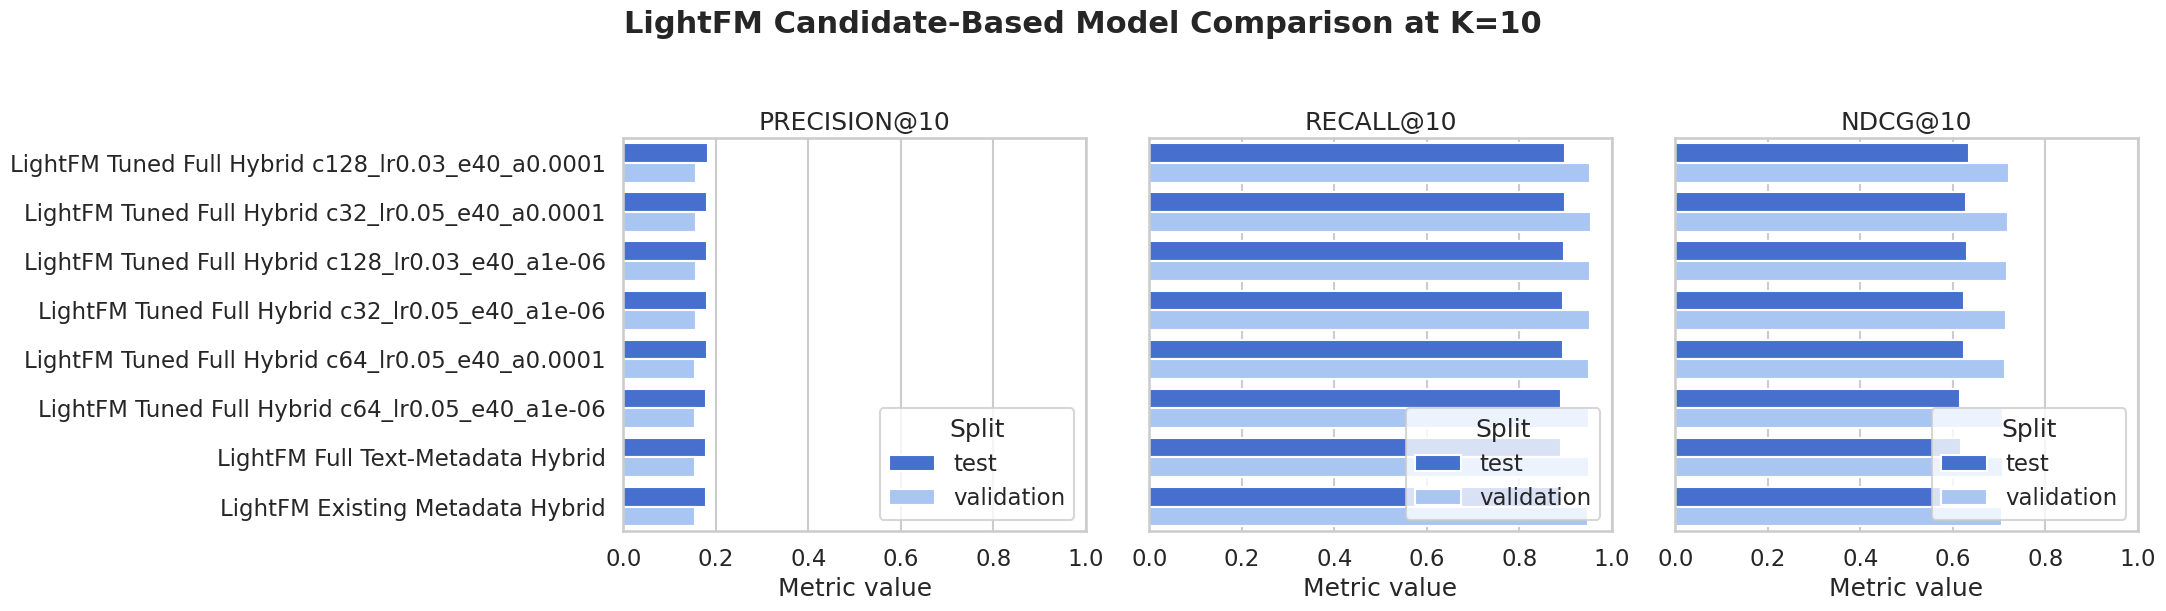

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
metrics = ["precision", "recall", "ndcg"]

comparison_clean = (
    all_comparison_df
    .drop_duplicates(subset=["model", "features", "split", "k"], keep="last")
    .copy()
)

k10_leaderboard = (
    comparison_clean[
        (comparison_clean["split"].isin(["validation", "test"])) &
        (comparison_clean["k"] == 10)
    ]
    .sort_values(["split", "ndcg"], ascending=[True, False])
    .reset_index(drop=True)
)

k10_leaderboard.to_csv(os.path.join(RESULT_DIR, "lightfm_model_leaderboard_k10.csv"), index=False)
display(k10_leaderboard)

plot_models = (
    k10_leaderboard[k10_leaderboard["split"] == "validation"]
    .sort_values("ndcg", ascending=False)
    .head(8)["model"]
    .tolist()
)
plot_long = k10_leaderboard[k10_leaderboard["model"].isin(plot_models)].melt(
    id_vars=["model", "features", "split", "k"],
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
for ax, metric in zip(axes, metrics):
    metric_df = plot_long[plot_long["metric"] == metric].copy()
    sns.barplot(
        data=metric_df,
        y="model",
        x="value",
        hue="split",
        order=plot_models,
        palette={"validation": "#9dc3ff", "test": "#2f66e5"},
        ax=ax
    )
    ax.set_title(f"{metric.upper()}@10")
    ax.set_xlabel("Metric value")
    ax.set_ylabel("")
    ax.set_xlim(0, 1)
    ax.legend(title="Split", loc="lower right")

plt.suptitle("LightFM Candidate-Based Model Comparison at K=10", y=1.03, fontsize=22, fontweight="bold")
plt.tight_layout()
plt.show()

,model,features,split,k,precision,recall,ndcg
67,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,test,5,0.259768,0.691299,0.549149
68,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,test,10,0.181998,0.899524,0.634325
69,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,test,20,0.106243,0.982474,0.666001
64,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,5,0.255650,0.843519,0.677257
65,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.156802,0.953836,0.721469
66,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,20,0.086405,0.990998,0.736110


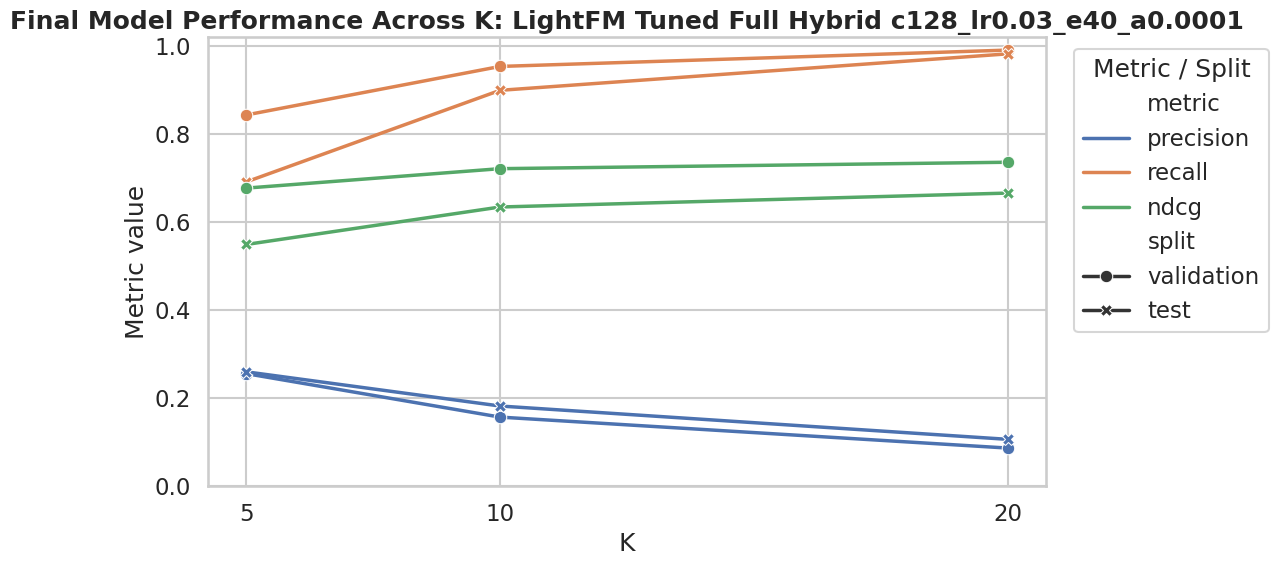

In [38]:
# Plot 2: final selected model performance across K.
final_curve_df = comparison_clean[
    (comparison_clean["model"] == best_model_name) &
    (comparison_clean["split"].isin(["validation", "test"]))
].copy()

final_curve_df.to_csv(os.path.join(RESULT_DIR, "lightfm_final_model_metrics_by_k.csv"), index=False)
display(final_curve_df.sort_values(["split", "k"]))

curve_long = final_curve_df.melt(
    id_vars=["model", "features", "split", "k"],
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=curve_long,
    x="k",
    y="value",
    hue="metric",
    style="split",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9
)
plt.title(f"Final Model Performance Across K: {best_model_name}", fontsize=18, fontweight="bold")
plt.xlabel("K")
plt.ylabel("Metric value")
plt.xticks([5, 10, 20])
plt.ylim(0, 1.02)
plt.legend(title="Metric / Split", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

,model,features,precision,recall,ndcg,ndcg_lift_vs_interaction,relative_lift_pct
0,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,0.181998,0.899524,0.634325,0.104453,19.712906
1,LightFM Tuned Full Hybrid c128_lr0.03_e40_a1e-06,User-item interactions + tags + numeric metada...,0.180823,0.896603,0.630098,0.100226,18.915182
2,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,0.181712,0.898792,0.629484,0.099612,18.799268
3,LightFM Tuned Full Hybrid c32_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,0.180284,0.895041,0.623531,0.093659,17.675840
4,LightFM Tuned Full Hybrid c64_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,0.179974,0.893960,0.623315,0.093443,17.634995
5,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,0.178488,0.889440,0.617421,0.087549,16.522701
6,LightFM Hybrid,User-item interactions + item metadata,0.178252,0.888899,0.616741,0.086870,16.394457
7,LightFM Existing Metadata Hybrid,User-item interactions + tags + numeric metada...,0.178026,0.888537,0.616242,0.086371,16.300272
8,LightFM Tuned Full Hybrid c64_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,0.178547,0.889569,0.616072,0.086200,16.268129
9,LightFM Tag Hybrid,User-item interactions + item tags,0.173481,0.873088,0.596735,0.066863,12.618693


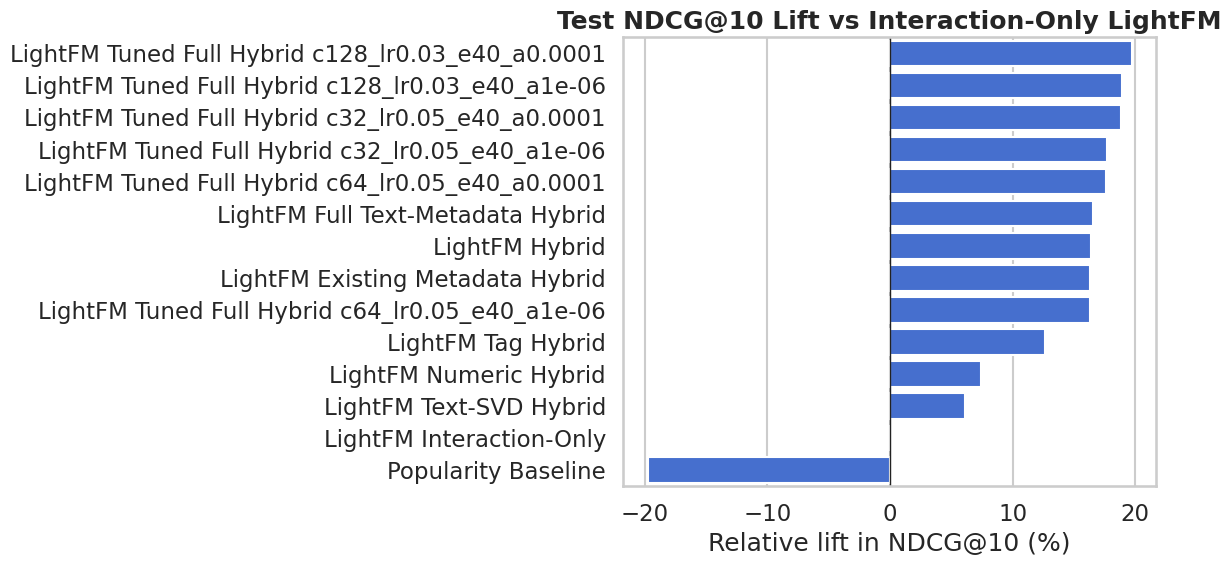

In [39]:
# Plot 3: feature ablation lift over interaction-only LightFM on test NDCG@10.
test_k10_clean = comparison_clean[
    (comparison_clean["split"] == "test") &
    (comparison_clean["k"] == 10)
].copy()

interaction_baseline = test_k10_clean[test_k10_clean["model"] == "LightFM Interaction-Only"]

if not interaction_baseline.empty:
    base_ndcg = interaction_baseline.iloc[0]["ndcg"]
    ablation_lift = test_k10_clean.copy()
    ablation_lift["ndcg_lift_vs_interaction"] = ablation_lift["ndcg"] - base_ndcg
    ablation_lift["relative_lift_pct"] = ablation_lift["ndcg_lift_vs_interaction"] / base_ndcg * 100
    ablation_lift = ablation_lift.sort_values("ndcg", ascending=False).reset_index(drop=True)

    ablation_lift.to_csv(os.path.join(RESULT_DIR, "lightfm_ablation_lift_vs_interaction_k10.csv"), index=False)
    display(ablation_lift[["model", "features", "precision", "recall", "ndcg", "ndcg_lift_vs_interaction", "relative_lift_pct"]])

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=ablation_lift,
        y="model",
        x="relative_lift_pct",
        color="#2f66e5"
    )
    plt.axvline(0, color="#222222", linewidth=1)
    plt.title("Test NDCG@10 Lift vs Interaction-Only LightFM", fontsize=18, fontweight="bold")
    plt.xlabel("Relative lift in NDCG@10 (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Interaction-only LightFM row not found; skipping lift plot.")

## 10. Save Final Model

In [40]:
final_model = None
final_item_features = None
final_model_source = None

if "tuned_models" in globals() and best_model_name in tuned_models:
    final_model = tuned_models[best_model_name]
    final_item_features = tuned_item_features[best_model_name]
    final_model_source = "hyperparameter_tuned_in_memory"
elif best_model_name.startswith("LightFM Tuned"):
    final_model = load_saved_model_if_available(best_model_name)
    final_item_features = TUNING_ITEM_FEATURES
    final_model_source = "hyperparameter_tuned_loaded_pickle" if final_model is not None else "hyperparameter_tuned_missing_pickle"
elif best_model_name in ablation_models:
    final_model = ablation_models[best_model_name]
    final_item_features = ablation_item_features[best_model_name]
    final_model_source = "ablation"
elif best_model_name == "LightFM Interaction-Only":
    final_model = interaction_model
    final_item_features = None
    final_model_source = "interaction_only"
elif best_model_name == "LightFM Hybrid":
    final_model = hybrid_model
    final_item_features = hybrid_item_features
    final_model_source = "initial_hybrid"

if final_model is None and best_model_name.startswith("LightFM Tuned"):
    print("Final tuned model object is missing because runtime disconnected and pickle was not found.")
    print("To avoid rerunning the whole grid, train only the selected best model once using the recovery cell below.")
else:
    with open(os.path.join(MODEL_DIR, "final_lightfm_model.pkl"), "wb") as f:
        pickle.dump(final_model, f)

    final_model_metadata = {
        "best_model_name": best_model_name,
        "best_features": best_features,
        "best_validation_ndcg@10": float(best_val_ndcg),
        "source": final_model_source,
        "regularization_summary": "L2 via item_alpha/user_alpha; embedding dimension limit via no_components; early-stopping check via validation learning curve.",
        "evaluation_note": "Main metrics are candidate-based sampled ranking metrics; full-catalog sanity check is reported separately."
    }

    with open(os.path.join(MODEL_DIR, "final_lightfm_model_metadata.pkl"), "wb") as f:
        pickle.dump(final_model_metadata, f)

    print("Saved final LightFM model:", os.path.join(MODEL_DIR, "final_lightfm_model.pkl"))
    print("Final model source:", final_model_source)
    print(final_model_metadata)

Loaded saved model: /content/drive/MyDrive/PixelRec50K_outputs/models/lightfm_tuned_full_hybrid_c128_lr0.03_e40_a0.0001.pkl
Saved final LightFM model: /content/drive/MyDrive/PixelRec50K_outputs/models/final_lightfm_model.pkl
Final model source: hyperparameter_tuned_loaded_pickle
{'best_model_name': 'LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001', 'best_features': 'User-item interactions + tags + numeric metadata + text SVD', 'best_validation_ndcg@10': 0.7214685873303364, 'source': 'hyperparameter_tuned_loaded_pickle', 'regularization_summary': 'L2 via item_alpha/user_alpha; embedding dimension limit via no_components; early-stopping check via validation learning curve.', 'evaluation_note': 'Main metrics are candidate-based sampled ranking metrics; full-catalog sanity check is reported separately.'}


Train Only the Selected Best Tuned Model

Run this cell only if the runtime disconnected, the tuning CSV exists or manual best row is available, but the saved model pickle is missing. This avoids rerunning the full six-model grid.


In [41]:
TRAIN_ONLY_BEST_TUNED_MODEL = False

if TRAIN_ONLY_BEST_TUNED_MODEL:
    best_tuning_row = tuning_results_df.sort_values("val_ndcg@10", ascending=False).iloc[0]
    recovered_model_name = best_tuning_row["model"]

    print("Training only the selected best tuned model:", recovered_model_name)
    final_model = train_lightfm_model(
        item_features=TUNING_ITEM_FEATURES,
        epochs=int(best_tuning_row["epochs"]),
        no_components=int(best_tuning_row["no_components"]),
        learning_rate=float(best_tuning_row["learning_rate"]),
        item_alpha=float(best_tuning_row["item_alpha"]),
        user_alpha=float(best_tuning_row["user_alpha"]),
        random_state=RANDOM_STATE
    )
    final_item_features = TUNING_ITEM_FEATURES
    save_model(final_model, recovered_model_name)

    with open(os.path.join(MODEL_DIR, "final_lightfm_model.pkl"), "wb") as f:
        pickle.dump(final_model, f)

    print("Recovered and saved final tuned model.")
else:
    print("Skipped. Set TRAIN_ONLY_BEST_TUNED_MODEL = True only if the best-model pickle is missing.")

Skipped. Set TRAIN_ONLY_BEST_TUNED_MODEL = True only if the best-model pickle is missing.


## 11. Epoch Learning Curve and Early-Stopping Check

This section evaluates the final hybrid feature set at cumulative epochs 5/10/20/30/40. It is the early-stopping component of regularization: if training NDCG keeps rising while validation NDCG plateaus or declines, the best validation epoch should be preferred over simply training longer.

Epoch: 100%|██████████| 5/5 [01:32<00:00, 18.40s/it]


,epoch,split,ndcg@10
0,5,train,0.569748
1,5,validation,0.200210
2,10,train,0.570860
3,10,validation,0.200549


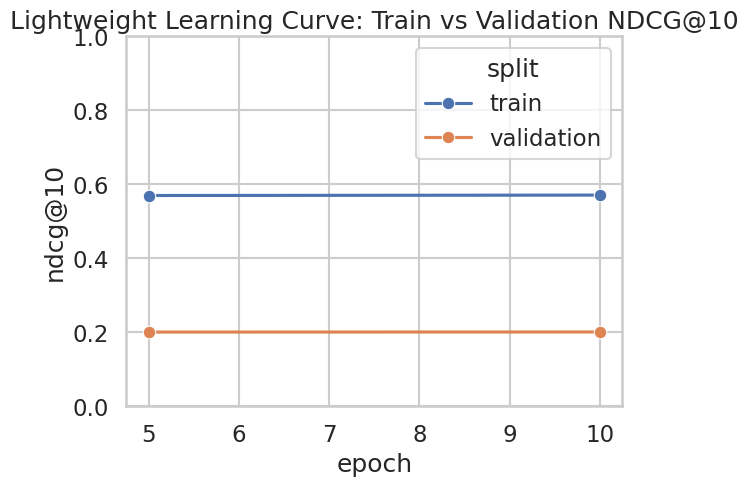

In [44]:
RUN_EPOCH_LEARNING_CURVE = True

EPOCH_CHECKPOINTS = [5, 10]
LEARNING_CURVE_COMPONENTS = 32
LEARNING_CURVE_LR = 0.05
LEARNING_CURVE_ALPHA = 1e-4

train_curve_samples = train_samples.sample(n=20000, random_state=RANDOM_STATE)
val_curve_samples = val_samples.sample(n=20000, random_state=RANDOM_STATE)

learning_curve_rows = []
previous_epoch = 0

learning_curve_model = LightFM(
    loss="warp",
    no_components=LEARNING_CURVE_COMPONENTS,
    learning_rate=LEARNING_CURVE_LR,
    item_alpha=LEARNING_CURVE_ALPHA,
    user_alpha=LEARNING_CURVE_ALPHA,
    random_state=RANDOM_STATE
)

for epoch in EPOCH_CHECKPOINTS:
    additional_epochs = epoch - previous_epoch
    previous_epoch = epoch

    learning_curve_model.fit_partial(
        train_matrix,
        item_features=TUNING_ITEM_FEATURES,
        epochs=additional_epochs,
        num_threads=NUM_THREADS,
        verbose=True
    )

    train_summary, _ = evaluate_lightfm_on_samples(
        learning_curve_model,
        train_curve_samples,
        item_features=TUNING_ITEM_FEATURES,
        k_values=[10]
    )

    val_summary, _ = evaluate_lightfm_on_samples(
        learning_curve_model,
        val_curve_samples,
        item_features=TUNING_ITEM_FEATURES,
        k_values=[10]
    )

    learning_curve_rows.extend([
        {"epoch": epoch, "split": "train", "ndcg@10": train_summary.loc[0, "ndcg"]},
        {"epoch": epoch, "split": "validation", "ndcg@10": val_summary.loc[0, "ndcg"]},
    ])

learning_curve_df = pd.DataFrame(learning_curve_rows)
display(learning_curve_df)

sns.lineplot(
    data=learning_curve_df,
    x="epoch",
    y="ndcg@10",
    hue="split",
    marker="o"
)
plt.title("Lightweight Learning Curve: Train vs Validation NDCG@10")
plt.ylim(0, 1)
plt.show()

The lightweight learning-curve check shows a clear train-validation gap: training NDCG@10 is around 0.57, while validation NDCG@10 stays around 0.20. This suggests that the model fits the training candidates much better than unseen validation candidates.

Increasing training from 5 to 10 epochs provides almost no validation improvement, indicating that additional epochs alone may not improve generalization. This supports the use of regularization and validation-based model selection.

## 12. Final Solution + Regularization Summary

This section identifies the selected model, supports selection with validation results, explains regularization, lists key settings, and summarizes the trade-off between complexity, accuracy, interpretability, and generalization.

In [45]:
# Criterion 6 summary tables: final selected model, regularization, settings, and trade-offs.

# 1) Final model selection evidence from validation NDCG@10.
final_selection_summary = selection_df.head(10).copy()
final_selection_summary.to_csv(os.path.join(RESULT_DIR, "criterion6_final_model_selection_validation.csv"), index=False)
display(final_selection_summary)

# 2) Extract final model settings where possible.
final_model_settings = {
    "Selected model": best_model_name,
    "Feature set": best_features,
    "Selection criterion": "Highest validation NDCG@10 among LightFM candidates",
    "Loss": "WARP ranking loss",
    "Optimizer / training algorithm": "LightFM internal asynchronous SGD over sampled ranking violations",
    "Evaluation mode": "Candidate-based ranking; full-catalog sanity check reported separately",
    "GPU usage": "LightFM is CPU/Cython-based; GPU is not used for training. NUM_THREADS controls CPU parallelism.",
}

if "tuning_results_df" in globals() and not tuning_results_df.empty and best_model_name in set(tuning_results_df["model"]):
    best_tuned_row = tuning_results_df[tuning_results_df["model"] == best_model_name].iloc[0]
    final_model_settings.update({
        "Embedding size / components": int(best_tuned_row["no_components"]),
        "Learning rate": float(best_tuned_row["learning_rate"]),
        "Training epochs": int(best_tuned_row["epochs"]),
        "L2 item_alpha": float(best_tuned_row["item_alpha"]),
        "L2 user_alpha": float(best_tuned_row["user_alpha"]),
        "Regularization label": best_tuned_row.get("regularization_label", "not specified"),
    })
else:
    final_model_settings.update({
        "Embedding size / components": "64 for initial/ablation models unless otherwise specified",
        "Learning rate": "0.05 for initial/ablation models unless otherwise specified",
        "Training epochs": "40 for initial/ablation models",
        "L2 item_alpha": "1e-6 for initial/ablation models",
        "L2 user_alpha": "1e-6 for initial/ablation models",
        "Regularization label": "weak L2 baseline",
    })

settings_df = pd.DataFrame(final_model_settings.items(), columns=["Setting", "Value"])
settings_df.to_csv(os.path.join(RESULT_DIR, "criterion6_final_model_key_settings.csv"), index=False)
display(settings_df)

# 3) Regularization evidence.
regularization_evidence_rows = []

if "tuning_results_df" in globals() and not tuning_results_df.empty:
    reg_cols = [
        "model", "no_components", "learning_rate", "epochs", "item_alpha", "user_alpha",
        "regularization_label", "val_ndcg@10", "test_ndcg@10"
    ]
    available_reg_cols = [c for c in reg_cols if c in tuning_results_df.columns]
    regularization_tuning_table = tuning_results_df[available_reg_cols].copy()
    regularization_tuning_table.to_csv(os.path.join(RESULT_DIR, "criterion6_l2_dimension_regularization_sweep.csv"), index=False)
    display(regularization_tuning_table)

    best_reg = tuning_results_df.sort_values("val_ndcg@10", ascending=False).iloc[0]
    regularization_evidence_rows.append({
        "Regularization mechanism": "L2 embedding penalty",
        "Implementation": "LightFM item_alpha and user_alpha",
        "Evidence used": f"Tuning compared alpha values; best validation NDCG@10 = {best_reg['val_ndcg@10']:.4f}",
        "Interpretation": "Higher alpha limits embedding magnitude; selected value balances fit and generalization."
    })

    regularization_evidence_rows.append({
        "Regularization mechanism": "Embedding dimension limit",
        "Implementation": "no_components grid over 32, 64, 128",
        "Evidence used": "Validation NDCG@10 selected model capacity rather than using the largest model by default.",
        "Interpretation": "Smaller dimensions improve interpretability and reduce overfitting risk; larger dimensions may improve accuracy but add variance."
    })

if "learning_curve_df" in globals() and not learning_curve_df.empty:
    validation_curve = learning_curve_df[learning_curve_df["split"] == "validation"].copy()
    best_epoch_row = validation_curve.sort_values("ndcg@10", ascending=False).iloc[0]
    regularization_evidence_rows.append({
        "Regularization mechanism": "Early stopping check",
        "Implementation": "fit_partial learning curve at epochs 5/10/20/30/40",
        "Evidence used": f"Best validation epoch = {int(best_epoch_row['epoch'])}, validation NDCG@10 = {best_epoch_row['ndcg@10']:.4f}",
        "Interpretation": "Training duration is selected by validation behavior instead of assuming more epochs always generalize better."
    })

regularization_evidence_rows.append({
    "Regularization mechanism": "Dropout",
    "Implementation": "Not applicable to LightFM",
    "Evidence used": "LightFM is a matrix-factorization / hybrid linear embedding model, not a neural network with hidden layers.",
    "Interpretation": "The appropriate regularizers here are L2 penalties, capacity control, and early stopping rather than dropout."
})

regularization_evidence_df = pd.DataFrame(regularization_evidence_rows)
regularization_evidence_df.to_csv(os.path.join(RESULT_DIR, "criterion6_regularization_evidence.csv"), index=False)
display(regularization_evidence_df)

# 4) Complexity / accuracy / interpretability / generalization trade-off.
tradeoff_df = pd.DataFrame([
    {
        "Decision": "Hybrid LightFM instead of popularity baseline",
        "Accuracy impact": "Adds personalization and item-content signal",
        "Complexity cost": "Requires user/item embeddings and item feature matrix",
        "Interpretability": "Moderate: feature ablations and nearest neighbors explain parts of the model",
        "Generalization": "Better for sparse items than interaction-only models if metadata is informative"
    },
    {
        "Decision": "WARP ranking loss",
        "Accuracy impact": "Optimizes Top-N ranking directly",
        "Complexity cost": "Training is slower than simple popularity or pointwise losses",
        "Interpretability": "Less direct than simple counts, but aligned with recommendation objective",
        "Generalization": "Validation NDCG@10 is used to guard against ranking overfit"
    },
    {
        "Decision": "L2 alpha + dimension sweep",
        "Accuracy impact": "Searches for best validation NDCG@10",
        "Complexity cost": "Multiple model fits",
        "Interpretability": "Smaller embeddings are easier to justify",
        "Generalization": "Limits embedding magnitude and capacity"
    },
    {
        "Decision": "Early-stopping check",
        "Accuracy impact": "Avoids keeping epochs that only improve training metrics",
        "Complexity cost": "Additional partial-fit evaluations",
        "Interpretability": "Clear train-vs-validation curve",
        "Generalization": "Selects training duration based on validation behavior"
    }
])
tradeoff_df.to_csv(os.path.join(RESULT_DIR, "criterion6_tradeoff_summary.csv"), index=False)
display(tradeoff_df)

,model,features,split,k,precision,recall,ndcg
0,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.156802,0.953836,0.721469
1,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.157183,0.955035,0.719919
2,LightFM Tuned Full Hybrid c128_lr0.03_e40_a1e-06,User-item interactions + tags + numeric metada...,validation,10,0.156261,0.952547,0.717751
3,LightFM Tuned Full Hybrid c32_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,validation,10,0.156366,0.952919,0.715945
4,LightFM Tuned Full Hybrid c64_lr0.05_e40_a0.0001,User-item interactions + tags + numeric metada...,validation,10,0.155499,0.950188,0.712135
5,LightFM Tuned Full Hybrid c64_lr0.05_e40_a1e-06,User-item interactions + tags + numeric metada...,validation,10,0.155133,0.949682,0.709036
6,LightFM Full Text-Metadata Hybrid,User-item interactions + tags + numeric metada...,validation,10,0.155284,0.949964,0.707714
7,LightFM Existing Metadata Hybrid,User-item interactions + tags + numeric metada...,validation,10,0.154880,0.948908,0.707059
8,LightFM Hybrid,User-item interactions + item metadata,validation,10,0.155260,0.949773,0.706889
9,LightFM Tag Hybrid,User-item interactions + item tags,validation,10,0.152249,0.941436,0.688441


,Setting,Value
0,Selected model,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001
1,Feature set,User-item interactions + tags + numeric metada...
2,Selection criterion,Highest validation NDCG@10 among LightFM candi...
3,Loss,WARP ranking loss
4,Optimizer / training algorithm,LightFM internal asynchronous SGD over sampled...
5,Evaluation mode,Candidate-based ranking; full-catalog sanity c...
6,GPU usage,LightFM is CPU/Cython-based; GPU is not used f...
7,Embedding size / components,128
8,Learning rate,0.03
9,Training epochs,40


,model,no_components,learning_rate,epochs,item_alpha,user_alpha,val_ndcg@10,test_ndcg@10
0,LightFM Tuned Full Hybrid c128_lr0.03_e40_a0.0001,128,0.03,40,0.000100,0.000100,0.721469,0.634325
1,LightFM Tuned Full Hybrid c32_lr0.05_e40_a0.0001,32,0.05,40,0.000100,0.000100,0.719919,0.629484
2,LightFM Tuned Full Hybrid c128_lr0.03_e40_a1e-06,128,0.03,40,0.000001,0.000001,0.717751,0.630098
3,LightFM Tuned Full Hybrid c32_lr0.05_e40_a1e-06,32,0.05,40,0.000001,0.000001,0.715945,0.623531
4,LightFM Tuned Full Hybrid c64_lr0.05_e40_a0.0001,64,0.05,40,0.000100,0.000100,0.712135,0.623315
5,LightFM Tuned Full Hybrid c64_lr0.05_e40_a1e-06,64,0.05,40,0.000001,0.000001,0.709036,0.616072


,Regularization mechanism,Implementation,Evidence used,Interpretation
0,L2 embedding penalty,LightFM item_alpha and user_alpha,Tuning compared alpha values; best validation ...,Higher alpha limits embedding magnitude; selec...
1,Embedding dimension limit,"no_components grid over 32, 64, 128",Validation NDCG@10 selected model capacity rat...,Smaller dimensions improve interpretability an...
2,Early stopping check,fit_partial learning curve at epochs 5/10/20/3...,"Best validation epoch = 10, validation NDCG@10...",Training duration is selected by validation be...
3,Dropout,Not applicable to LightFM,LightFM is a matrix-factorization / hybrid lin...,The appropriate regularizers here are L2 penal...


,Decision,Accuracy impact,Complexity cost,Interpretability,Generalization
0,Hybrid LightFM instead of popularity baseline,Adds personalization and item-content signal,Requires user/item embeddings and item feature...,Moderate: feature ablations and nearest neighb...,Better for sparse items than interaction-only ...
1,WARP ranking loss,Optimizes Top-N ranking directly,Training is slower than simple popularity or p...,"Less direct than simple counts, but aligned wi...",Validation NDCG@10 is used to guard against ra...
2,L2 alpha + dimension sweep,Searches for best validation NDCG@10,Multiple model fits,Smaller embeddings are easier to justify,Limits embedding magnitude and capacity
3,Early-stopping check,Avoids keeping epochs that only improve traini...,Additional partial-fit evaluations,Clear train-vs-validation curve,Selects training duration based on validation ...


## 13. User-Level NDCG Distribution

Mean NDCG@10 hides whether improvement is broad-based or driven by a few users. This histogram compares the final candidate model against the popularity baseline when user-level result files are available.

Saved popularity user-level file not found; computing popularity baseline inline for test_samples.


,count,mean,std,min,25%,50%,75%,max
model_group,,,,,,,,
Final LightFM,49950.0,0.634325,0.245473,0.0,0.437349,0.613147,0.850345,1.0
Popularity Baseline,49950.0,0.425454,0.261655,0.0,0.231570,0.386853,0.580549,1.0


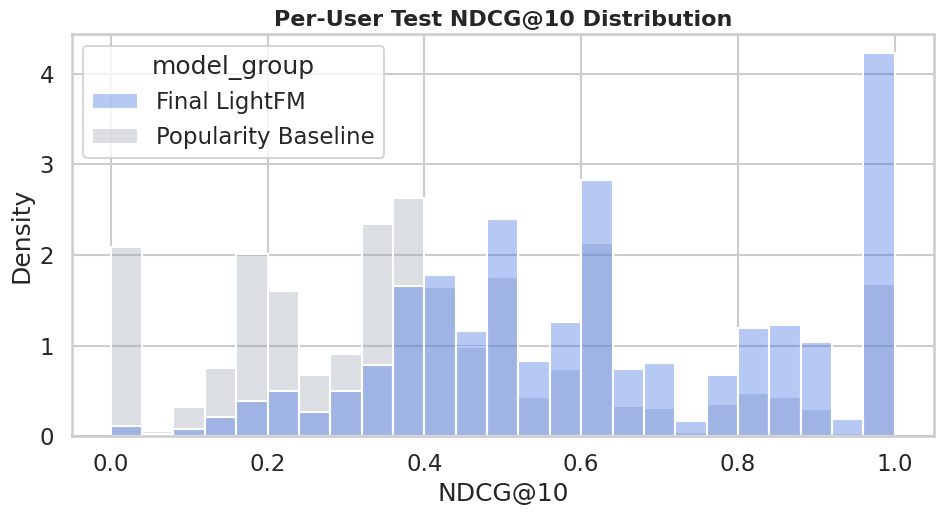

In [46]:
def load_user_level_results_if_exists(path):
    return pd.read_csv(path) if os.path.exists(path) else pd.DataFrame()

def evaluate_popularity_on_samples_user_level(samples_df, train_df, k_values=[10]):
    """Compute popularity baseline user-level metrics inline if no saved file exists."""
    item_popularity = train_df.groupby("item_idx").size().rename("popularity")
    rows = []

    for user_idx, user_data in samples_df.groupby("user_idx", sort=False):
        user_data = user_data.copy()
        user_data["popularity"] = user_data["item_idx"].map(item_popularity).fillna(0)
        user_data = user_data.sort_values(["popularity", "item_idx"], ascending=[False, True])

        ranked_items = user_data["item_idx"].tolist()
        relevant_items = user_data.loc[user_data["label"] == 1, "item_idx"].unique().tolist()

        for k in k_values:
            rows.append({
                "user_idx": int(user_idx),
                "k": int(k),
                "precision": precision_at_k(ranked_items, relevant_items, k),
                "recall": recall_at_k(ranked_items, relevant_items, k),
                "ndcg": ndcg_at_k(ranked_items, relevant_items, k),
                "split": "test",
                "model": "Popularity Baseline"
            })

    return pd.DataFrame(rows)

# Final model user-level metrics are saved in the final K re-evaluation cell if the final model is tuned.
final_user_path = os.path.join(RESULT_DIR, "final_model_user_level_candidate_metrics.csv")
final_user_level = load_user_level_results_if_exists(final_user_path)

# Fall back to ablation user-level results if the selected model was an ablation model.
if final_user_level.empty and "ablation_user_results_df" in globals():
    final_user_level = ablation_user_results_df[
        ablation_user_results_df["model"] == best_model_name
    ].copy()

pop_user_candidates = [
    os.path.join(RESULT_DIR, "popularity_baseline_user_level_results.csv"),
    os.path.join(DATASET_DIR, "results", "popularity_baseline_user_level_results.csv"),
]
pop_user_level = pd.DataFrame()
for pop_user_path in pop_user_candidates:
    pop_user_level = load_user_level_results_if_exists(pop_user_path)
    if not pop_user_level.empty:
        print("Loaded user-level popularity baseline from:", pop_user_path)
        break

if pop_user_level.empty:
    print("Saved popularity user-level file not found; computing popularity baseline inline for test_samples.")
    pop_user_level = evaluate_popularity_on_samples_user_level(test_samples, train_df, k_values=[10])
    pop_user_level.to_csv(os.path.join(RESULT_DIR, "popularity_baseline_user_level_results_inline.csv"), index=False)

hist_parts = []
if not final_user_level.empty:
    hist_parts.append(final_user_level[(final_user_level["split"] == "test") & (final_user_level["k"] == 10)].assign(model_group="Final LightFM"))
if not pop_user_level.empty:
    hist_parts.append(pop_user_level[(pop_user_level["split"] == "test") & (pop_user_level["k"] == 10)].assign(model_group="Popularity Baseline"))

if hist_parts:
    ndcg_distribution_df = pd.concat(hist_parts, ignore_index=True)
    ndcg_distribution_df.to_csv(os.path.join(RESULT_DIR, "ndcg10_user_distribution_final_vs_baseline.csv"), index=False)
    display(ndcg_distribution_df.groupby("model_group")["ndcg"].describe())

    plt.figure(figsize=(10, 5.5))
    sns.histplot(
        data=ndcg_distribution_df,
        x="ndcg",
        hue="model_group",
        bins=25,
        stat="density",
        common_norm=False,
        alpha=0.35,
        palette={"Final LightFM": "#2f66e5", "Popularity Baseline": "#9aa4b2"}
    )
    plt.title("Per-User Test NDCG@10 Distribution", fontsize=16, fontweight="bold")
    plt.xlabel("NDCG@10")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()
else:
    print("Final user-level metrics are missing. Re-run final model evaluation before plotting this distribution.")

The final LightFM model shifts the per-user NDCG@10 distribution to the right. Mean NDCG@10 improves from 0.425 to 0.634, and median NDCG@10 improves from 0.387 to 0.613, showing broad user-level gains over the popularity baseline.

## 14. Cold-Item Slice Analysis

Hybrid recommendation is most useful if metadata helps with sparse or long-tail items.

,item_frequency_bin,users_evaluated,candidate_rows,precision@10,recall@10,ndcg@10,model
0,0,8810,13930,0.119296,0.999981,0.965081,Final LightFM
1,1-4,20976,72507,0.136942,0.998073,0.870826,Final LightFM
2,5-9,17541,100289,0.121783,0.992331,0.785234,Final LightFM
3,10+,33028,269119,0.148737,0.977614,0.731344,Final LightFM
4,0,8810,13930,0.119308,1.000000,0.943380,Interaction-Only LightFM
5,1-4,20976,72507,0.135784,0.995732,0.812554,Interaction-Only LightFM
6,5-9,17541,100289,0.118910,0.979932,0.709160,Interaction-Only LightFM
7,10+,33028,269119,0.143660,0.959981,0.664280,Interaction-Only LightFM


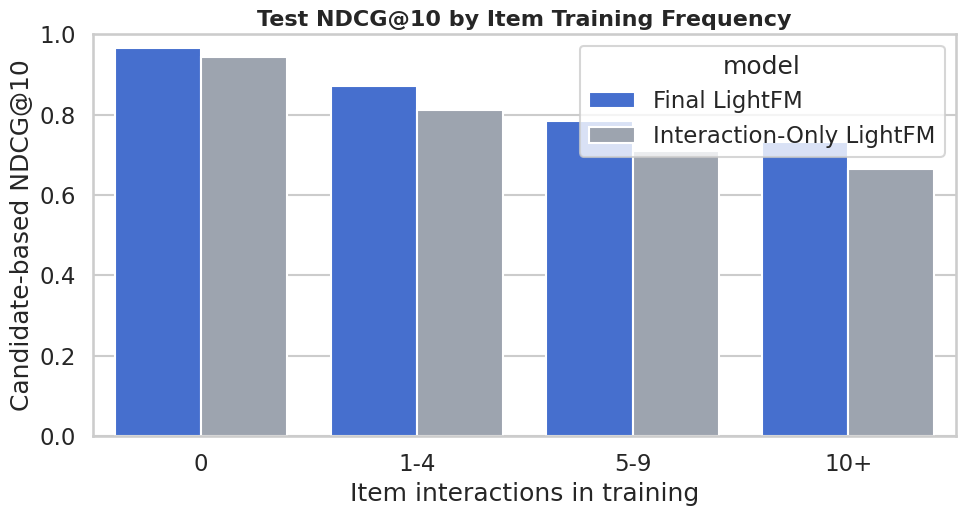

In [47]:
def add_item_frequency_bins(samples_df, train_df):
    """Attach item training-frequency bins to a candidate sample dataframe.
    """
    item_train_counts = train_df.groupby("item_idx").size().rename("train_item_count").reset_index()
    out = samples_df.merge(item_train_counts, on="item_idx", how="left")
    out["train_item_count"] = out["train_item_count"].fillna(0).astype(int)
    out["item_frequency_bin"] = pd.cut(
        out["train_item_count"],
        bins=[-1, 0, 4, 9, np.inf],
        labels=["0", "1-4", "5-9", "10+"]
    )
    return out

def evaluate_by_item_frequency_bin(model, samples_df, train_df, item_features=None, k=10):
    """Evaluate candidate-based NDCG@K separately within item-frequency bins.
    """
    samples_with_bins = add_item_frequency_bins(samples_df, train_df)
    rows = []

    for bin_name, bin_df in samples_with_bins.groupby("item_frequency_bin", observed=True):
        # Keep only users with at least one positive candidate inside this bin.
        positive_users = bin_df.loc[bin_df["label"] == 1, "user_idx"].unique()
        bin_eval_df = bin_df[bin_df["user_idx"].isin(positive_users)].copy()

        if bin_eval_df.empty:
            continue

        summary, user_results = evaluate_lightfm_on_samples(
            model,
            bin_eval_df,
            item_features=item_features,
            k_values=[k]
        )

        rows.append({
            "item_frequency_bin": str(bin_name),
            "users_evaluated": int(user_results["user_idx"].nunique()),
            "candidate_rows": int(len(bin_eval_df)),
            "precision@10": summary.loc[0, "precision"],
            "recall@10": summary.loc[0, "recall"],
            "ndcg@10": summary.loc[0, "ndcg"],
        })

    return pd.DataFrame(rows)

if final_model is not None:
    cold_slice_final = evaluate_by_item_frequency_bin(
        final_model,
        test_samples,
        train_df,
        item_features=final_item_features,
        k=10
    ).assign(model="Final LightFM")

    cold_slice_parts = [cold_slice_final]
    if "interaction_model" in globals():
        cold_slice_interaction = evaluate_by_item_frequency_bin(
            interaction_model,
            test_samples,
            train_df,
            item_features=None,
            k=10
        ).assign(model="Interaction-Only LightFM")
        cold_slice_parts.append(cold_slice_interaction)

    cold_slice_df = pd.concat(cold_slice_parts, ignore_index=True)
    cold_slice_df.to_csv(os.path.join(RESULT_DIR, "cold_item_frequency_slice_ndcg10.csv"), index=False)
    display(cold_slice_df)

    plt.figure(figsize=(10, 5.5))
    sns.barplot(
        data=cold_slice_df,
        x="item_frequency_bin",
        y="ndcg@10",
        hue="model",
        palette={"Final LightFM": "#2f66e5", "Interaction-Only LightFM": "#9aa4b2"}
    )
    plt.title("Test NDCG@10 by Item Training Frequency", fontsize=16, fontweight="bold")
    plt.xlabel("Item interactions in training")
    plt.ylabel("Candidate-based NDCG@10")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Final model is not available yet. Run final model selection first.")

## 15. Item Embedding Nearest Neighbors

This qualitative check opens the model box by asking whether nearby item embeddings have similar titles/tags. It supports the results section by showing what the latent item space learned.

In [48]:
from sklearn.metrics.pairwise import cosine_similarity

# Build metadata lookup locally so this cell can run independently of the NDCG walkthrough section.
if "item_metadata_lookup" not in globals():
    item_lookup = (
        pd.concat([
            train_df[["item_idx", "item_id"]],
            val_df[["item_idx", "item_id"]],
            test_df[["item_idx", "item_id"]]
        ], ignore_index=True)
        .drop_duplicates(subset=["item_idx"])
    )

    item_info_path = os.path.join(DATASET_DIR, "pixel50k_item_info.csv")
    item_info = pd.read_csv(item_info_path)
    metadata_cols = [c for c in ["item_id", "title", "tag", "description"] if c in item_info.columns]
    item_metadata_lookup = item_lookup.merge(item_info[metadata_cols], on="item_id", how="left")

if "clean_slide_text" not in globals():
    def clean_slide_text(value, max_len=70):
        if pd.isna(value):
            return "Unknown"
        value = str(value).replace("\n", " ").strip()
        return value if len(value) <= max_len else value[: max_len - 3] + "..."

def get_effective_item_embeddings(model, item_features=None):
    """Return the item representation actually used by LightFM scoring.
    """
    if item_features is None:
        return np.asarray(model.item_embeddings)
    return np.asarray(item_features.dot(model.item_embeddings))

if final_model is not None:
    effective_item_embeddings = get_effective_item_embeddings(final_model, final_item_features)
    item_norms = np.linalg.norm(effective_item_embeddings, axis=1, keepdims=True)
    normalized_item_embeddings = effective_item_embeddings / np.maximum(item_norms, 1e-12)

    popular_items = (
        train_df.groupby("item_idx")
        .size()
        .rename("train_count")
        .reset_index()
        .sort_values("train_count", ascending=False)
    )

    example_seed_items = popular_items.head(200).sample(min(3, len(popular_items.head(200))), random_state=RANDOM_STATE)["item_idx"].tolist()
    neighbor_rows = []

    for seed_item_idx in example_seed_items:
        seed_vector = normalized_item_embeddings[int(seed_item_idx)].reshape(1, -1)
        sims = cosine_similarity(seed_vector, normalized_item_embeddings).ravel()
        neighbor_indices = np.argsort(-sims)[1:6]

        for rank, neighbor_idx in enumerate(neighbor_indices, start=1):
            neighbor_rows.append({
                "seed_item_idx": int(seed_item_idx),
                "neighbor_rank": rank,
                "neighbor_item_idx": int(neighbor_idx),
                "cosine_similarity": float(sims[neighbor_idx]),
                "embedding_type": "effective hybrid item embedding" if final_item_features is not None else "item-id embedding"
            })

    nearest_neighbors_df = pd.DataFrame(neighbor_rows)

    seed_meta = item_metadata_lookup.rename(columns={
        "item_idx": "seed_item_idx",
        "item_id": "seed_item_id",
        "title": "seed_title",
        "tag": "seed_tag"
    })[["seed_item_idx", "seed_item_id", "seed_title", "seed_tag"]]

    neighbor_meta = item_metadata_lookup.rename(columns={
        "item_idx": "neighbor_item_idx",
        "item_id": "neighbor_item_id",
        "title": "neighbor_title",
        "tag": "neighbor_tag"
    })[["neighbor_item_idx", "neighbor_item_id", "neighbor_title", "neighbor_tag"]]

    nearest_neighbors_df = nearest_neighbors_df.merge(seed_meta, on="seed_item_idx", how="left")
    nearest_neighbors_df = nearest_neighbors_df.merge(neighbor_meta, on="neighbor_item_idx", how="left")
    nearest_neighbors_df["seed_title"] = nearest_neighbors_df["seed_title"].apply(lambda x: clean_slide_text(x, 70))
    nearest_neighbors_df["neighbor_title"] = nearest_neighbors_df["neighbor_title"].apply(lambda x: clean_slide_text(x, 70))

    nearest_neighbors_df.to_csv(os.path.join(RESULT_DIR, "final_model_item_embedding_nearest_neighbors.csv"), index=False)
    display(nearest_neighbors_df[[
        "embedding_type", "seed_title", "seed_tag", "neighbor_rank", "neighbor_title", "neighbor_tag", "cosine_similarity"
    ]])
else:
    print("Final model is not available yet. Run final model selection first.")

,embedding_type,seed_title,seed_tag,neighbor_rank,neighbor_title,neighbor_tag,cosine_similarity
0,effective hybrid item embedding,Rating! I'm sure there's a madness with this o...,Miscellaneous,1,Rating! Mastering the Code of Success! Why thi...,Miscellaneous,0.821942
1,effective hybrid item embedding,Rating! I'm sure there's a madness with this o...,Miscellaneous,2,"The worst one-night seal of approval ever, wit...",Miscellaneous,0.810063
2,effective hybrid item embedding,Rating! I'm sure there's a madness with this o...,Miscellaneous,3,The masterpiece that influenced millions of vi...,Miscellaneous,0.799554
3,effective hybrid item embedding,Rating! I'm sure there's a madness with this o...,Miscellaneous,4,It's milkfan time! July's most anticipated ani...,Miscellaneous,0.792714
4,effective hybrid item embedding,Rating! I'm sure there's a madness with this o...,Miscellaneous,5,July's Most Amazing Anime! The production is s...,Miscellaneous,0.787323
5,effective hybrid item embedding,"Homemade dynamic cycling soybean milk machine,...",Handicraft,1,"The family dog likes to bite my slippers, own ...",Handicraft,0.923214
6,effective hybrid item embedding,"Homemade dynamic cycling soybean milk machine,...",Handicraft,2,Homemade Mosquito Coil Separator,Handicraft,0.908884
7,effective hybrid item embedding,"Homemade dynamic cycling soybean milk machine,...",Handicraft,3,Homemade sausage sashimi companion eat sausage...,Handicraft,0.906085
8,effective hybrid item embedding,"Homemade dynamic cycling soybean milk machine,...",Handicraft,4,"Good business project, sharing bench",Handicraft,0.904611
9,effective hybrid item embedding,"Homemade dynamic cycling soybean milk machine,...",Handicraft,5,Beauty Physics Outside Big Eye Glasses,Handicraft,0.904527


## 16. Small Full-Catalog Ranking Sanity Check

The main metrics are candidate-based. This section runs a small, slower full-catalog check on a sample of test users by ranking all items and removing items already seen in training.

In [49]:
def evaluate_full_catalog_sample(model, test_df, train_df, item_features=None, k_values=[10, 20], max_users=50, random_state=RANDOM_STATE):

    rng = np.random.default_rng(random_state)
    eligible_users = test_df["user_idx"].drop_duplicates().to_numpy()
    if len(eligible_users) > max_users:
        selected_users = rng.choice(eligible_users, size=max_users, replace=False)
    else:
        selected_users = eligible_users

    all_items = np.arange(num_items, dtype=np.int32)
    train_seen = train_df.groupby("user_idx")["item_idx"].apply(set).to_dict()
    test_relevant = test_df.groupby("user_idx")["item_idx"].apply(set).to_dict()

    rows = []
    for user_idx in selected_users:
        user_idx = int(user_idx)
        relevant_items = list(test_relevant.get(user_idx, set()))
        if not relevant_items:
            continue

        seen_items = train_seen.get(user_idx, set())
        candidate_mask = np.ones(num_items, dtype=bool)
        if seen_items:
            candidate_mask[list(seen_items)] = False
        candidate_items = all_items[candidate_mask]
        user_array = np.full(len(candidate_items), user_idx, dtype=np.int32)

        scores = model.predict(
            user_array,
            candidate_items,
            item_features=item_features,
            num_threads=NUM_THREADS
        )
        ranked_items = candidate_items[np.argsort(-scores)].tolist()

        for k in k_values:
            rows.append({
                "user_idx": user_idx,
                "k": k,
                "precision": precision_at_k(ranked_items, relevant_items, k),
                "recall": recall_at_k(ranked_items, relevant_items, k),
                "ndcg": ndcg_at_k(ranked_items, relevant_items, k),
                "candidate_count": len(candidate_items),
                "relevant_count": len(relevant_items)
            })

    user_results = pd.DataFrame(rows)
    summary = user_results.groupby("k")[["precision", "recall", "ndcg", "candidate_count", "relevant_count"]].mean().reset_index()
    return summary, user_results

RUN_FULL_CATALOG_SANITY_CHECK = True  # Keep True for the final notebook so the sanity-check output is visible.

if RUN_FULL_CATALOG_SANITY_CHECK and final_model is not None:
    full_catalog_summary, full_catalog_user_results = evaluate_full_catalog_sample(
        final_model,
        test_df,
        train_df,
        item_features=final_item_features,
        k_values=[10, 20],
        max_users=50
    )
    full_catalog_summary.to_csv(os.path.join(RESULT_DIR, "full_catalog_sanity_check_summary.csv"), index=False)
    full_catalog_user_results.to_csv(os.path.join(RESULT_DIR, "full_catalog_sanity_check_user_results.csv"), index=False)
    display(full_catalog_summary)
else:
    print("Full-catalog sanity check skipped. Set RUN_FULL_CATALOG_SANITY_CHECK = True after final_model is available.")

,k,precision,recall,ndcg,candidate_count,relevant_count
0,10,0.004,0.02,0.012105,47307.86,2.28
1,20,0.002,0.02,0.012105,47307.86,2.28


# NDCG@10 Walkthrough for One User

This section creates a slide-ready example that opens the NDCG "black box." It selects one user whose top-10 recommendation list has a clear mix of relevant and non-relevant items, joins item metadata, and calculates DCG, IDCG, and NDCG step by step.

In [50]:
import math

K_WALKTHROUGH = 10

if final_model is None:
    raise ValueError("final_model is not available. Run the final model selection and save-model cells first.")

def dcg_at_k_from_labels(labels, k=10):
    """Compute DCG@K from a binary relevance-label list already ordered by model rank."""
    labels = np.asarray(labels, dtype=float)[:k]
    if len(labels) == 0:
        return 0.0
    discounts = 1 / np.log2(np.arange(2, len(labels) + 2))
    return float(np.sum(labels * discounts))

def idcg_at_k_from_labels(labels, k=10):
    """Compute the ideal DCG@K by sorting the same relevance labels in descending order."""
    ideal_labels = np.sort(np.asarray(labels, dtype=float))[::-1][:k]
    return dcg_at_k_from_labels(ideal_labels, k=k)

def ndcg_at_k_from_labels(labels, candidate_labels=None, k=10):
    """Return DCG, IDCG, and NDCG for the NDCG walkthrough table.
    """
    dcg = dcg_at_k_from_labels(labels, k=k)
    idcg_source = labels if candidate_labels is None else candidate_labels
    idcg = idcg_at_k_from_labels(idcg_source, k=k)
    return dcg, idcg, (dcg / idcg if idcg > 0 else 0.0)

def rank_user_candidates(user_idx, samples_df, model, item_features=None, k=10):
    """Rank one user's sampled candidates and return top-K rows plus NDCG components."""
    user_candidates = samples_df[samples_df["user_idx"] == user_idx].copy()
    if user_candidates.empty:
        return None

    candidate_item_idx = user_candidates["item_idx"].to_numpy(dtype=np.int32)
    candidate_user_idx = np.full(len(candidate_item_idx), int(user_idx), dtype=np.int32)

    user_candidates["score"] = model.predict(
        candidate_user_idx,
        candidate_item_idx,
        item_features=item_features,
        num_threads=NUM_THREADS
    )

    ranked = user_candidates.sort_values("score", ascending=False).head(k).copy()
    ranked["rank"] = np.arange(1, len(ranked) + 1)
    ranked["discount"] = 1 / np.log2(ranked["rank"] + 1)
    ranked["dcg_contribution"] = ranked["label"] * ranked["discount"]

    dcg, idcg, ndcg = ndcg_at_k_from_labels(
        ranked["label"].to_numpy(),
        candidate_labels=user_candidates["label"].to_numpy(),
        k=k
    )

    return ranked, user_candidates, dcg, idcg, ndcg

In [51]:
# Choose a user that is easy to explain on a slide.
# Selection rule: pick a user with NDCG@10 near 0.70, close enough to the model
# average to be representative but low enough to show meaningful ranking errors.
# Requiring 2-5 relevant items in top-10 keeps the visual table readable.
example_rows = []

for user_idx in test_samples["user_idx"].drop_duplicates().head(10000):
    result = rank_user_candidates(
        user_idx=user_idx,
        samples_df=test_samples,
        model=final_model,
        item_features=final_item_features,
        k=K_WALKTHROUGH
    )
    if result is None:
        continue

    ranked, user_candidates, dcg, idcg, ndcg = result
    relevant_in_topk = int(ranked["label"].sum())
    total_relevant_candidates = int(user_candidates["label"].sum())

    if 2 <= relevant_in_topk <= 5 and total_relevant_candidates >= relevant_in_topk and 0.35 <= ndcg <= 0.95:
        example_rows.append({
            "user_idx": int(user_idx),
            "relevant_in_top10": relevant_in_topk,
            "total_relevant_candidates": total_relevant_candidates,
            "dcg@10": dcg,
            "idcg@10": idcg,
            "ndcg@10": ndcg,
            "distance_from_target": abs(ndcg - 0.70)
        })

example_user_candidates = (
    pd.DataFrame(example_rows)
    .sort_values(["distance_from_target", "relevant_in_top10"], ascending=[True, False])
    .reset_index(drop=True)
)

if example_user_candidates.empty:
    raise ValueError("No suitable walkthrough user found in the first 10,000 test users. Relax the selection criteria.")

display(example_user_candidates.head(10))

EXAMPLE_USER_IDX = int(example_user_candidates.loc[0, "user_idx"])
print("Selected walkthrough user_idx:", EXAMPLE_USER_IDX)

,user_idx,relevant_in_top10,total_relevant_candidates,dcg@10,idcg@10,ndcg@10,distance_from_target
0,16353,3,5,2.061606,2.948459,0.699215,0.000785
1,4641,3,5,2.061606,2.948459,0.699215,0.000785
2,11146,5,6,2.310281,3.304666,0.699097,0.000903
3,22943,4,6,2.317529,3.304666,0.701290,0.001290
4,19602,3,4,1.789065,2.561606,0.698415,0.001585
5,30397,3,4,1.789065,2.561606,0.698415,0.001585
6,21588,4,6,2.318813,3.304666,0.701678,0.001678
7,17773,5,7,2.553075,3.638000,0.701780,0.001780
8,2911,4,4,1.788167,2.561606,0.698065,0.001935
9,40380,3,3,1.487137,2.130930,0.697882,0.002118


Selected walkthrough user_idx: 16353


In [52]:
# Build metadata lookup tables.
item_lookup = (
    pd.concat([
        train_df[["item_idx", "item_id"]],
        val_df[["item_idx", "item_id"]],
        test_df[["item_idx", "item_id"]]
    ], ignore_index=True)
    .drop_duplicates(subset=["item_idx"])
)

item_info_path = os.path.join(DATASET_DIR, "pixel50k_item_info.csv")
if "item_info" not in globals():
    item_info = pd.read_csv(item_info_path)

metadata_cols = [c for c in ["item_id", "title", "tag", "description"] if c in item_info.columns]
item_metadata_lookup = item_lookup.merge(item_info[metadata_cols], on="item_id", how="left")

def clean_slide_text(value, max_len=70):
    if pd.isna(value):
        return "Unknown"
    value = str(value).replace("\n", " ").strip()
    return value if len(value) <= max_len else value[: max_len - 3] + "..."

ranked, user_candidates, dcg, idcg, ndcg = rank_user_candidates(
    user_idx=EXAMPLE_USER_IDX,
    samples_df=test_samples,
    model=final_model,
    item_features=final_item_features,
    k=K_WALKTHROUGH
)

walkthrough_table = ranked.merge(item_metadata_lookup, on="item_idx", how="left")
walkthrough_table["recommended_video"] = walkthrough_table["title"].apply(lambda x: clean_slide_text(x, 65))
walkthrough_table["tag_short"] = walkthrough_table["tag"].apply(lambda x: clean_slide_text(x, 35))
walkthrough_table["relevant"] = walkthrough_table["label"].map({1: "Yes", 0: "No"})
walkthrough_table["discount"] = walkthrough_table["discount"].round(3)
walkthrough_table["dcg_contribution"] = walkthrough_table["dcg_contribution"].round(3)
walkthrough_table["score"] = walkthrough_table["score"].round(4)

slide_walkthrough_table = walkthrough_table[[
    "rank", "recommended_video", "tag_short", "relevant", "discount", "dcg_contribution", "score"
]].copy()

print(f"Walkthrough user_idx: {EXAMPLE_USER_IDX}")
print(f"DCG@10:  {dcg:.3f}")
print(f"IDCG@10: {idcg:.3f}")
print(f"NDCG@10: {ndcg:.3f}")

display(slide_walkthrough_table)
slide_walkthrough_table.to_csv(os.path.join(RESULT_DIR, "ndcg_walkthrough_top10_table.csv"), index=False)

Walkthrough user_idx: 16353
DCG@10:  2.062
IDCG@10: 2.948
NDCG@10: 0.699


,rank,recommended_video,tag_short,relevant,discount,dcg_contribution,score
0,1,"Guan Yunchang: ""All the heroes of the world wi...",Miscellaneous,Yes,1.000,1.000,1.1757
1,2,Zhuge Liang: The only thing that can hack me i...,Humanities and History,Yes,0.631,0.631,0.7239
2,3,Millet and Jiuyang first cooperation to launch...,Digital,No,0.500,0.000,0.4745
3,4,Then I realized that swords used to be able to...,Film and TV Discussions,Yes,0.431,0.431,0.4340
4,5,"The CCTV-promoted Basket Out of the Future, wh...",Film and TV Discussions,No,0.387,0.000,0.3468
5,6,"Damn, I'm handsome again, is this leg length r...",Celebrities Mix,No,0.356,0.000,-0.2159
6,7,The Pokémon Light Pokémon is a pirated Pokémon...,Short Film·Hand-drawn·Dubbing,No,0.333,0.000,-0.3961
7,8,Put your clothes on! The most exposed and reve...,Miscellaneous,No,0.315,0.000,-0.5476
8,9,"""Lone Ranger.""",Miscellaneous,No,0.301,0.000,-0.5553
9,10,"The ""God of the Seals""] ""Daji"" is a true story.",Film and Television Editing,No,0.289,0.000,-0.6464


In [55]:
# Recent user history for the left side of the slide.
user_history = train_df[train_df["user_idx"] == EXAMPLE_USER_IDX].copy()

if "timestamp" in user_history.columns:
    user_history = user_history.sort_values("timestamp", ascending=False)

history_with_meta = (
    user_history.head(5)
    .merge(item_metadata_lookup, on="item_idx", how="left")
)

history_with_meta["item_id"] = history_with_meta["item_id_x"]

history_with_meta["watched_video"] = history_with_meta["title"].apply(lambda x: clean_slide_text(x, 70))
history_with_meta["tag_short"] = history_with_meta["tag"].apply(lambda x: clean_slide_text(x, 35))

history_slide_table = history_with_meta[["item_id", "watched_video", "tag_short"]].copy()

display(history_slide_table)
history_slide_table.to_csv(os.path.join(RESULT_DIR, "ndcg_walkthrough_user_history.csv"), index=False)

,item_id,watched_video,tag_short
0,i252395,She's not being mocked for playing a young gir...,Film and Television Editing
1,i198508,"""The Character of Heroes",Short Film·Hand-drawn·Dubbing
2,i109449,Cao Cao: Worthy of the planning ghostwriters!,Short Film·Hand-drawn·Dubbing
3,i152072,Three views are broken! Green tea mistress sis...,Film and TV Discussions
4,i52285,The first song of the year to be played was th...,Music Review


In [54]:
print(history_with_meta.columns.tolist())

['user_id', 'item_id_x', 'user_idx', 'item_idx', 'timestamp', 'datetime', 'item_id_y', 'title', 'tag', 'description', 'watched_video', 'tag_short']


In [56]:
# Step-by-step calculation table for the slide speaker notes.
calc_table = walkthrough_table[["rank", "label", "discount", "dcg_contribution"]].copy()
calc_table = calc_table.rename(columns={
    "label": "rel_i",
    "discount": "1/log2(i+1)",
    "dcg_contribution": "rel_i_discounted_gain"
})

num_relevant_for_idcg = min(int(user_candidates["label"].sum()), K_WALKTHROUGH)
ideal_labels = [1] * num_relevant_for_idcg + [0] * (K_WALKTHROUGH - num_relevant_for_idcg)
ideal_discounts = 1 / np.log2(np.arange(2, K_WALKTHROUGH + 2))
ideal_contrib = np.array(ideal_labels) * ideal_discounts

idcg_table = pd.DataFrame({
    "ideal_rank": np.arange(1, K_WALKTHROUGH + 1),
    "ideal_rel_i": ideal_labels,
    "discount": np.round(ideal_discounts, 3),
    "ideal_dcg_contribution": np.round(ideal_contrib, 3)
})

summary_formula = pd.DataFrame({
    "quantity": ["DCG@10", "IDCG@10", "NDCG@10"],
    "value": [round(dcg, 3), round(idcg, 3), round(ndcg, 3)],
    "slide_text": [
        f"DCG@10 = {dcg:.3f}",
        f"IDCG@10 = {idcg:.3f}",
        f"NDCG@10 = {dcg:.3f} / {idcg:.3f} = {ndcg:.3f}"
    ]
})

display(calc_table)
display(idcg_table.head(num_relevant_for_idcg))
display(summary_formula)

calc_table.to_csv(os.path.join(RESULT_DIR, "ndcg_walkthrough_dcg_steps.csv"), index=False)
idcg_table.to_csv(os.path.join(RESULT_DIR, "ndcg_walkthrough_idcg_steps.csv"), index=False)
summary_formula.to_csv(os.path.join(RESULT_DIR, "ndcg_walkthrough_summary.csv"), index=False)

,rank,rel_i,1/log2(i+1),rel_i_discounted_gain
0,1,1,1.000,1.000
1,2,1,0.631,0.631
2,3,0,0.500,0.000
3,4,1,0.431,0.431
4,5,0,0.387,0.000
5,6,0,0.356,0.000
6,7,0,0.333,0.000
7,8,0,0.315,0.000
8,9,0,0.301,0.000
9,10,0,0.289,0.000


,ideal_rank,ideal_rel_i,discount,ideal_dcg_contribution
0,1,1,1.000,1.000
1,2,1,0.631,0.631
2,3,1,0.500,0.500
3,4,1,0.431,0.431
4,5,1,0.387,0.387


,quantity,value,slide_text
0,DCG@10,2.062,DCG@10 = 2.062
1,IDCG@10,2.948,IDCG@10 = 2.948
2,NDCG@10,0.699,NDCG@10 = 2.062 / 2.948 = 0.699


This walkthrough shows how NDCG rewards ranking relevant videos early. The model placed relevant items at ranks 1, 2, and 4, giving DCG@10 = 2.062. The ideal ranking would place all five relevant items first, giving IDCG@10 = 2.948. Thus, NDCG@10 = 0.699, or about 70% of the ideal ranking quality.

More visuals

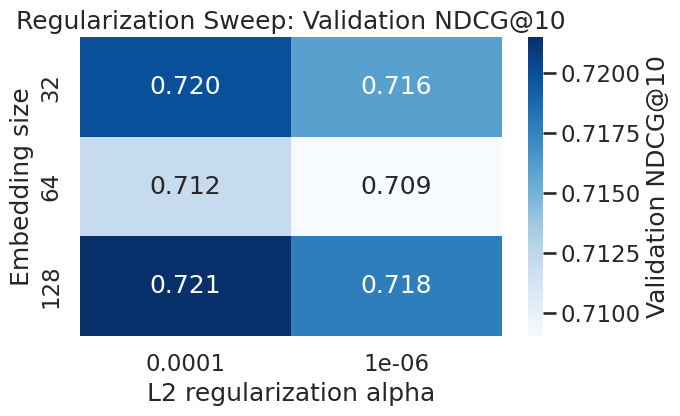

In [57]:
tuning_plot_df = tuning_results_df.copy()
tuning_plot_df["alpha"] = tuning_plot_df["item_alpha"].astype(str)

heatmap_df = tuning_plot_df.pivot_table(
    index="no_components",
    columns="alpha",
    values="val_ndcg@10",
    aggfunc="mean"
)

plt.figure(figsize=(7, 4.5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar_kws={"label": "Validation NDCG@10"}
)

plt.title("Regularization Sweep: Validation NDCG@10")
plt.xlabel("L2 regularization alpha")
plt.ylabel("Embedding size")
plt.tight_layout()
plt.show()

The best validation NDCG@10 comes from the 128-component model with stronger L2 regularization (`alpha=0.0001`). This suggests that higher capacity helps, but regularization is needed to control overfitting and improve generalization.

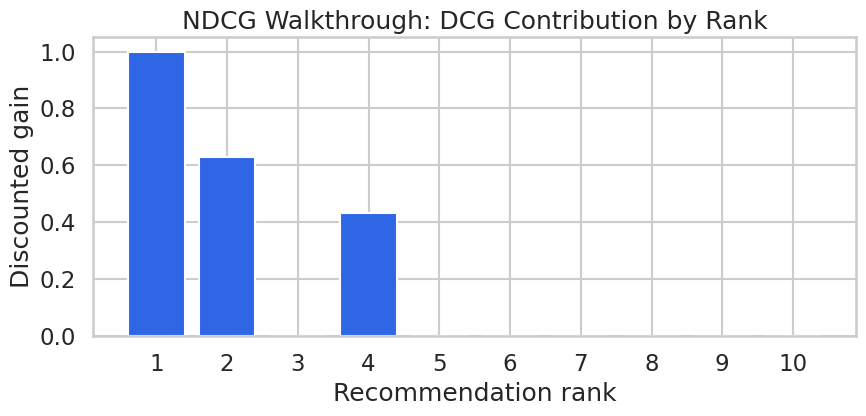

In [58]:
plt.figure(figsize=(9, 4.5))

colors = calc_table["rel_i"].map({1: "#2f66e5", 0: "#d0d5dd"})

plt.bar(
    calc_table["rank"],
    calc_table["rel_i_discounted_gain"],
    color=colors
)

plt.xticks(calc_table["rank"])
plt.xlabel("Recommendation rank")
plt.ylabel("Discounted gain")
plt.title("NDCG Walkthrough: DCG Contribution by Rank")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

This chart shows how each rank contributes to DCG@10. Relevant videos at ranks 1, 2, and 4 contribute positive discounted gain, while non-relevant videos contribute zero. This makes the NDCG calculation interpretable for one concrete user.